In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
m_conference= pd.read_csv("MConferenceTourneyGames.csv")
m_seeds= pd.read_csv("MNCAATourneySeeds.csv")
m_regular=pd.read_csv("MRegularSeasonCompactResults.csv")
m_tournament=pd.read_csv("MNCAATourneyCompactResults.csv")
m_tournament_all=pd.read_csv("MNCAATourneyDetailedResults.csv")
m_regular_all=pd.read_csv("MRegularSeasonDetailedResults.csv")


In [3]:
m_tournament.shape

(2518, 8)

In [4]:
m_tournament_all.shape

(1382, 34)

In [5]:
m_regular.shape

(190771, 8)

In [6]:
m_regular_all.shape

(116723, 34)

In [7]:
m_tournament_all

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,...,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,...,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,2024,146,1301,76,1181,64,N,0,28,60,...,20,21,26,10,27,11,9,4,5,23
1378,2024,146,1345,72,1397,66,N,0,24,53,...,26,7,11,6,17,17,6,8,4,25
1379,2024,152,1163,86,1104,72,N,0,31,62,...,23,9,11,7,21,9,7,2,5,15
1380,2024,152,1345,63,1301,50,N,0,22,55,...,19,3,4,6,22,10,11,8,3,13


In [8]:
m_regular_all

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116718,2025,85,1401,75,1328,68,H,0,21,56,...,22,16,22,2,16,19,8,6,10,25
116719,2025,85,1405,86,1325,83,A,0,34,64,...,19,13,17,7,25,11,4,1,5,15
116720,2025,85,1428,69,1153,66,H,0,26,49,...,22,14,22,6,15,11,12,5,6,17
116721,2025,85,1444,74,1123,71,A,0,28,58,...,21,15,24,14,21,11,1,4,12,15


In [9]:
#to know if all columns in both datasets are same



tourney_columns = set(m_tournament_all.columns)
regular_columns = set(m_regular_all.columns)


missing_in_regular = tourney_columns - regular_columns
missing_in_tourney = regular_columns - tourney_columns

In [10]:
missing_in_regular

set()

In [11]:
missing_in_tourney

set()

In [12]:
m_combined_data = pd.concat([m_regular_all, m_tournament_all], ignore_index=True)
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,20,21,26,10,27,11,9,4,5,23
118101,2024,146,1345,72,1397,66,N,0,24,53,...,26,7,11,6,17,17,6,8,4,25
118102,2024,152,1163,86,1104,72,N,0,31,62,...,23,9,11,7,21,9,7,2,5,15
118103,2024,152,1345,63,1301,50,N,0,22,55,...,19,3,4,6,22,10,11,8,3,13


In [13]:
m_combined_data.isnull().sum()

Season     0
DayNum     0
WTeamID    0
WScore     0
LTeamID    0
LScore     0
WLoc       0
NumOT      0
WFGM       0
WFGA       0
WFGM3      0
WFGA3      0
WFTM       0
WFTA       0
WOR        0
WDR        0
WAst       0
WTO        0
WStl       0
WBlk       0
WPF        0
LFGM       0
LFGA       0
LFGM3      0
LFGA3      0
LFTM       0
LFTA       0
LOR        0
LDR        0
LAst       0
LTO        0
LStl       0
LBlk       0
LPF        0
dtype: int64

In [14]:

m_combined_data["Lower_ID"] = m_combined_data[["WTeamID", "LTeamID"]].min(axis=1)
m_combined_data["Higher_ID"] = m_combined_data[["WTeamID", "LTeamID"]].max(axis=1)


m_combined_data["ID"] = (
    m_combined_data["Season"].astype(str) + "_" + 
    m_combined_data["Lower_ID"].astype(str) + "_" + 
    m_combined_data["Higher_ID"].astype(str)
)
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,Lower_ID,Higher_ID,ID
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,22,8,18,9,2,20,1104,1328,2003_1104_1328
1,2003,10,1272,70,1393,63,N,0,26,62,...,20,25,7,12,8,6,16,1272,1393,2003_1272_1393
2,2003,11,1266,73,1437,61,N,0,24,58,...,31,22,9,12,2,5,23,1266,1437,2003_1266_1437
3,2003,11,1296,56,1457,50,N,0,18,38,...,17,20,9,19,4,3,23,1296,1457,2003_1296_1457
4,2003,11,1400,77,1208,71,N,0,30,61,...,21,15,12,10,7,1,14,1208,1400,2003_1208_1400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,10,27,11,9,4,5,23,1181,1301,2024_1181_1301
118101,2024,146,1345,72,1397,66,N,0,24,53,...,6,17,17,6,8,4,25,1345,1397,2024_1345_1397
118102,2024,152,1163,86,1104,72,N,0,31,62,...,7,21,9,7,2,5,15,1104,1163,2024_1104_1163
118103,2024,152,1345,63,1301,50,N,0,22,55,...,6,22,10,11,8,3,13,1301,1345,2024_1301_1345


In [15]:

m_combined_data["Lower_ID"] = m_combined_data[["WTeamID", "LTeamID"]].min(axis=1)
m_combined_data["Higher_ID"] = m_combined_data[["WTeamID", "LTeamID"]].max(axis=1)

m_combined_data["Results"] = (m_combined_data["WTeamID"] == m_combined_data["Lower_ID"]).astype(int)
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LDR,LAst,LTO,LStl,LBlk,LPF,Lower_ID,Higher_ID,ID,Results
0,2003,10,1104,68,1328,62,N,0,27,58,...,22,8,18,9,2,20,1104,1328,2003_1104_1328,1
1,2003,10,1272,70,1393,63,N,0,26,62,...,25,7,12,8,6,16,1272,1393,2003_1272_1393,1
2,2003,11,1266,73,1437,61,N,0,24,58,...,22,9,12,2,5,23,1266,1437,2003_1266_1437,1
3,2003,11,1296,56,1457,50,N,0,18,38,...,20,9,19,4,3,23,1296,1457,2003_1296_1457,1
4,2003,11,1400,77,1208,71,N,0,30,61,...,15,12,10,7,1,14,1208,1400,2003_1208_1400,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,27,11,9,4,5,23,1181,1301,2024_1181_1301,0
118101,2024,146,1345,72,1397,66,N,0,24,53,...,17,17,6,8,4,25,1345,1397,2024_1345_1397,1
118102,2024,152,1163,86,1104,72,N,0,31,62,...,21,9,7,2,5,15,1104,1163,2024_1104_1163,0
118103,2024,152,1345,63,1301,50,N,0,22,55,...,22,10,11,8,3,13,1301,1345,2024_1301_1345,0


In [16]:
#to see if all the combinations exist in m_combined_data

m_teams = pd.read_csv("MTeams.csv")

active_mteams = m_teams[m_teams["LastD1Season"] == 2025][["TeamID"]]

m_matchups = active_mteams.merge(active_mteams, how="cross")

m_matchups =m_matchups[m_matchups["TeamID_x"] < m_matchups["TeamID_y"]]

m_matchups = m_matchups.rename(columns={"TeamID_x": "Lower_ID", "TeamID_y": "Higher_ID"})

m_matchups["Season"] = 2025

m_matchups["ID"] = (
    m_matchups["Season"].astype(str) + "_" +
    m_matchups["Lower_ID"].astype(str) + "_" +
    m_matchups["Higher_ID"].astype(str)
)

m_matchups

,Lower_ID,Higher_ID,Season,ID
1,1101,1102,2025,2025_1101_1102
2,1101,1103,2025,2025_1101_1103
3,1101,1104,2025,2025_1101_1104
4,1101,1105,2025,2025_1101_1105
5,1101,1106,2025,2025_1101_1106
...,...,...,...,...
131402,1477,1479,2025,2025_1477_1479
131403,1477,1480,2025,2025_1477_1480
131766,1478,1479,2025,2025_1478_1479
131767,1478,1480,2025,2025_1478_1480


In [17]:

m_matchups_set = set(m_matchups[["Lower_ID", "Higher_ID"]].itertuples(index=False, name=None))
m_combined_set = set(m_combined_data[["Lower_ID", "Higher_ID"]].itertuples(index=False, name=None))


missing_matchups = m_matchups_set - m_combined_set


In [18]:
missing_matchups

{(1352, 1469),
 (1393, 1470),
 (1164, 1418),
 (1217, 1244),
 (1203, 1346),
 (1277, 1295),
 (1428, 1464),
 (1106, 1413),
 (1180, 1362),
 (1254, 1311),
 (1240, 1413),
 (1271, 1480),
 (1405, 1480),
 (1105, 1188),
 (1229, 1254),
 (1182, 1408),
 (1256, 1357),
 (1347, 1475),
 (1421, 1424),
 (1159, 1424),
 (1332, 1352),
 (1423, 1470),
 (1115, 1125),
 (1133, 1142),
 (1119, 1244),
 (1171, 1434),
 (1458, 1464),
 (1210, 1362),
 (1284, 1311),
 (1270, 1413),
 (1344, 1362),
 (1435, 1480),
 (1135, 1188),
 (1173, 1480),
 (1247, 1429),
 (1286, 1357),
 (1115, 1475),
 (1148, 1423),
 (1189, 1424),
 (1249, 1475),
 (1166, 1440),
 (1224, 1418),
 (1265, 1419),
 (1201, 1434),
 (1126, 1260),
 (1143, 1429),
 (1124, 1187),
 (1165, 1188),
 (1203, 1480),
 (1217, 1378),
 (1277, 1429),
 (1318, 1430),
 (1316, 1357),
 (1101, 1203),
 (1142, 1204),
 (1202, 1255),
 (1233, 1322),
 (1293, 1373),
 (1353, 1424),
 (1196, 1440),
 (1295, 1419),
 (1328, 1367),
 (1154, 1214),
 (1107, 1368),
 (1231, 1434),
 (1348, 1430),
 (1119, 13

In [19]:
if not missing_matchups:
    print("All matchups in `m_matchups` exist in `m_combined_data`.")
else:
    print(f" {len(missing_matchups)} matchups are missing from training data:")
    print(missing_matchups)  # Print missing matchups

 43034 matchups are missing from training data:
{(1352, 1469), (1393, 1470), (1164, 1418), (1217, 1244), (1203, 1346), (1277, 1295), (1428, 1464), (1106, 1413), (1180, 1362), (1254, 1311), (1240, 1413), (1271, 1480), (1405, 1480), (1105, 1188), (1229, 1254), (1182, 1408), (1256, 1357), (1347, 1475), (1421, 1424), (1159, 1424), (1332, 1352), (1423, 1470), (1115, 1125), (1133, 1142), (1119, 1244), (1171, 1434), (1458, 1464), (1210, 1362), (1284, 1311), (1270, 1413), (1344, 1362), (1435, 1480), (1135, 1188), (1173, 1480), (1247, 1429), (1286, 1357), (1115, 1475), (1148, 1423), (1189, 1424), (1249, 1475), (1166, 1440), (1224, 1418), (1265, 1419), (1201, 1434), (1126, 1260), (1143, 1429), (1124, 1187), (1165, 1188), (1203, 1480), (1217, 1378), (1277, 1429), (1318, 1430), (1316, 1357), (1101, 1203), (1142, 1204), (1202, 1255), (1233, 1322), (1293, 1373), (1353, 1424), (1196, 1440), (1295, 1419), (1328, 1367), (1154, 1214), (1107, 1368), (1231, 1434), (1348, 1430), (1119, 1378), (1232, 1255),

In [20]:
m_combined_data.columns.tolist()

['Season',
 'DayNum',
 'WTeamID',
 'WScore',
 'LTeamID',
 'LScore',
 'WLoc',
 'NumOT',
 'WFGM',
 'WFGA',
 'WFGM3',
 'WFGA3',
 'WFTM',
 'WFTA',
 'WOR',
 'WDR',
 'WAst',
 'WTO',
 'WStl',
 'WBlk',
 'WPF',
 'LFGM',
 'LFGA',
 'LFGM3',
 'LFGA3',
 'LFTM',
 'LFTA',
 'LOR',
 'LDR',
 'LAst',
 'LTO',
 'LStl',
 'LBlk',
 'LPF',
 'Lower_ID',
 'Higher_ID',
 'ID',
 'Results']

In [21]:
m_combined_data.columns.tolist()

['Season',
 'DayNum',
 'WTeamID',
 'WScore',
 'LTeamID',
 'LScore',
 'WLoc',
 'NumOT',
 'WFGM',
 'WFGA',
 'WFGM3',
 'WFGA3',
 'WFTM',
 'WFTA',
 'WOR',
 'WDR',
 'WAst',
 'WTO',
 'WStl',
 'WBlk',
 'WPF',
 'LFGM',
 'LFGA',
 'LFGM3',
 'LFGA3',
 'LFTM',
 'LFTA',
 'LOR',
 'LDR',
 'LAst',
 'LTO',
 'LStl',
 'LBlk',
 'LPF',
 'Lower_ID',
 'Higher_ID',
 'ID',
 'Results']

In [22]:

m_combined_data["W_TS%"] = (m_combined_data["WScore"] / 
                            (2 * (m_combined_data["WFGA"] + 0.44 * m_combined_data["WFTA"]))) * 100

m_combined_data["L_TS%"] = (m_combined_data["LScore"] / 
                            (2 * (m_combined_data["LFGA"] + 0.44 * m_combined_data["LFTA"]))) * 100


m_combined_data["Lower_ID_TS%"] = m_combined_data["W_TS%"].where(
    m_combined_data["Lower_ID"] == m_combined_data["WTeamID"], 
    m_combined_data["L_TS%"]
)

m_combined_data["Higher_ID_TS%"] = m_combined_data["W_TS%"].where(
    m_combined_data["Higher_ID"] == m_combined_data["WTeamID"], 
    m_combined_data["L_TS%"]
)


m_combined_data["TS%_diff"] = m_combined_data["Lower_ID_TS%"] - m_combined_data["Higher_ID_TS%"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LPF,Lower_ID,Higher_ID,ID,Results,W_TS%,L_TS%,Lower_ID_TS%,Higher_ID_TS%,TS%_diff
0,2003,10,1104,68,1328,62,N,0,27,58,...,20,1104,1328,2003_1104_1328,1,51.577670,49.457562,51.577670,49.457562,2.120108
1,2003,10,1272,70,1393,63,N,0,26,62,...,16,1272,1393,2003_1272_1393,1,49.744173,41.556728,49.744173,41.556728,8.187445
2,2003,11,1266,73,1437,61,N,0,24,58,...,23,1266,1437,2003_1266_1437,1,51.582815,36.693936,51.582815,36.693936,14.888879
3,2003,11,1296,56,1457,50,N,0,18,38,...,23,1296,1457,2003_1296_1457,1,54.221534,44.964029,54.221534,44.964029,9.257505
4,2003,11,1400,77,1208,71,N,0,30,61,...,14,1208,1400,2003_1208_1400,0,57.703837,48.050893,48.050893,57.703837,-9.652944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,23,1181,1301,2024_1181_1301,0,54.192812,45.428734,45.428734,54.192812,-8.764079
118101,2024,146,1345,72,1397,66,N,0,24,53,...,25,1345,1397,2024_1345_1397,1,53.317536,49.371634,53.317536,49.371634,3.945902
118102,2024,152,1163,86,1104,72,N,0,31,62,...,15,1104,1163,2024_1104_1163,0,61.498856,57.288351,57.288351,61.498856,-4.210504
118103,2024,152,1345,63,1301,50,N,0,22,55,...,13,1301,1345,2024_1301_1345,0,53.030303,42.545950,42.545950,53.030303,-10.484353


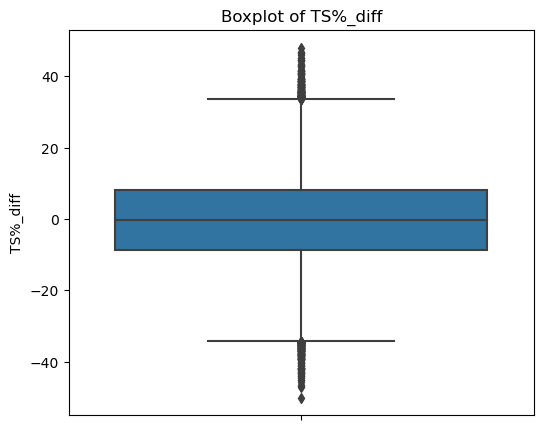

In [23]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["TS%_diff"])
plt.title("Boxplot of TS%_diff")
plt.show()

In [24]:
Q1 = m_combined_data["TS%_diff"].quantile(0.25)
Q3 = m_combined_data["TS%_diff"].quantile(0.75)
IQR = Q3 - Q1


lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR


outliers_below_iqr = (m_combined_data["TS%_diff"] < lower_bound_iqr).sum()
outliers_above_iqr = (m_combined_data["TS%_diff"] > upper_bound_iqr).sum()

In [25]:
outliers_below_iqr

197

In [26]:
outliers_above_iqr

203

In [27]:
m_combined_data.shape

(118105, 43)

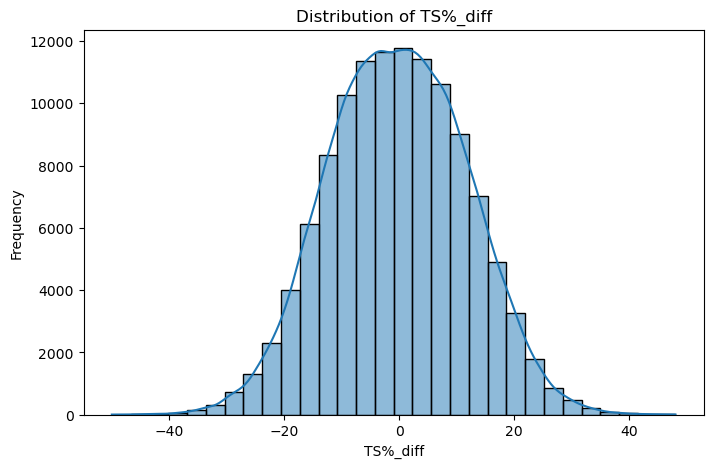

In [28]:

plt.figure(figsize=(8,5))
sns.histplot(m_combined_data["TS%_diff"], bins=30, kde=True)
plt.title("Distribution of TS%_diff")
plt.xlabel("TS%_diff")
plt.ylabel("Frequency")
plt.show()

In [29]:
from scipy.stats import skew
skewness_value = skew(m_combined_data["TS%_diff"], nan_policy='omit')
skewness_value

C:\Users\aksha\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1070: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


nan

In [30]:

inf_rows_ts = m_combined_data[np.isinf(m_combined_data["TS%_diff"])]
inf_rows_ts

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LPF,Lower_ID,Higher_ID,ID,Results,W_TS%,L_TS%,Lower_ID_TS%,Higher_ID_TS%,TS%_diff
118094,2024,144,1181,54,1222,51,N,0,0,0,...,12,1181,1222,2024_1181_1222,1,inf,45.148725,inf,45.148725,inf


In [31]:
m_combined_data["TS%_diff"] = np.clip(m_combined_data["TS%_diff"], lower_bound_iqr, upper_bound_iqr)

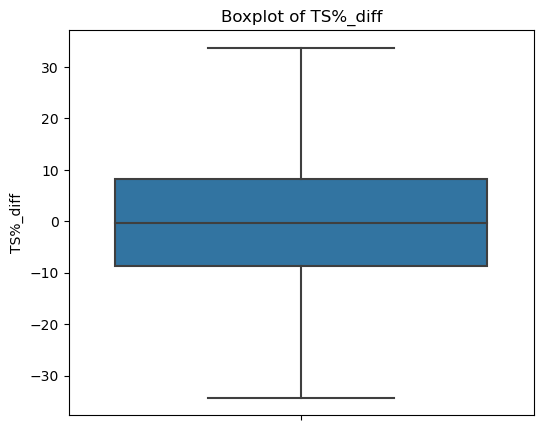

In [32]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["TS%_diff"])
plt.title("Boxplot of TS%_diff")
plt.show()


In [33]:
num_nulls = m_combined_data["TS%_diff"].isna().sum()


Q1 = m_combined_data["TS%_diff"].quantile(0.25)
Q3 = m_combined_data["TS%_diff"].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers_below = (m_combined_data["TS%_diff"] < lower_bound).sum()
outliers_above = (m_combined_data["TS%_diff"] > upper_bound).sum()
total_outliers = outliers_below + outliers_above


print(f"Number of NaN values in TS%_diff: {num_nulls}")
print(f"Number of outliers below lower bound: {outliers_below}")
print(f"Number of outliers above upper bound: {outliers_above}")
print(f"Total number of outliers in TS%_diff: {total_outliers}")


Number of NaN values in TS%_diff: 0
Number of outliers below lower bound: 0
Number of outliers above upper bound: 0
Total number of outliers in TS%_diff: 0


In [34]:

from scipy.stats import pointbiserialr


correlation, p_value = pointbiserialr(m_combined_data["TS%_diff"], m_combined_data["Results"])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial Correlation: 0.7181
P-value: 0.0000


In [35]:


m_seeds

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374
...,...,...,...
2553,2024,Z12,1241
2554,2024,Z13,1436
2555,2024,Z14,1324
2556,2024,Z15,1443


In [36]:

m_seeds["SeedValue"] = m_seeds["Seed"].str.extract(r'(\d+)').astype(int)


m_combined_data = m_combined_data.merge(
    m_seeds[["Season", "TeamID", "SeedValue"]],
    left_on=["Season", "Lower_ID"],
    right_on=["Season", "TeamID"],
    how="left"
).rename(columns={"SeedValue": "Lower_ID_Seed"}).drop(columns=["TeamID"])


m_combined_data = m_combined_data.merge(
    m_seeds[["Season", "TeamID", "SeedValue"]],
    left_on=["Season", "Higher_ID"],
    right_on=["Season", "TeamID"],
    how="left"
).rename(columns={"SeedValue": "Higher_ID_Seed"}).drop(columns=["TeamID"])


m_combined_data["Seed_Difference"] = m_combined_data["Higher_ID_Seed"] - m_combined_data["Lower_ID_Seed"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,ID,Results,W_TS%,L_TS%,Lower_ID_TS%,Higher_ID_TS%,TS%_diff,Lower_ID_Seed,Higher_ID_Seed,Seed_Difference
0,2003,10,1104,68,1328,62,N,0,27,58,...,2003_1104_1328,1,51.577670,49.457562,51.577670,49.457562,2.120108,10.0,1.0,-9.0
1,2003,10,1272,70,1393,63,N,0,26,62,...,2003_1272_1393,1,49.744173,41.556728,49.744173,41.556728,8.187445,7.0,3.0,-4.0
2,2003,11,1266,73,1437,61,N,0,24,58,...,2003_1266_1437,1,51.582815,36.693936,51.582815,36.693936,14.888879,3.0,NaN,NaN
3,2003,11,1296,56,1457,50,N,0,18,38,...,2003_1296_1457,1,54.221534,44.964029,54.221534,44.964029,9.257505,NaN,NaN,NaN
4,2003,11,1400,77,1208,71,N,0,30,61,...,2003_1208_1400,0,57.703837,48.050893,48.050893,57.703837,-9.652944,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,2024_1181_1301,0,54.192812,45.428734,45.428734,54.192812,-8.764079,4.0,11.0,7.0
118101,2024,146,1345,72,1397,66,N,0,24,53,...,2024_1345_1397,1,53.317536,49.371634,53.317536,49.371634,3.945902,1.0,2.0,1.0
118102,2024,152,1163,86,1104,72,N,0,31,62,...,2024_1104_1163,0,61.498856,57.288351,57.288351,61.498856,-4.210504,4.0,1.0,-3.0
118103,2024,152,1345,63,1301,50,N,0,22,55,...,2024_1301_1345,0,53.030303,42.545950,42.545950,53.030303,-10.484353,11.0,1.0,-10.0


In [37]:
null_counts = m_combined_data.isnull().sum()
null_counts

Season                  0
DayNum                  0
WTeamID                 0
WScore                  0
LTeamID                 0
LScore                  0
WLoc                    0
NumOT                   0
WFGM                    0
WFGA                    0
WFGM3                   0
WFGA3                   0
WFTM                    0
WFTA                    0
WOR                     0
WDR                     0
WAst                    0
WTO                     0
WStl                    0
WBlk                    0
WPF                     0
LFGM                    0
LFGA                    0
LFGM3                   0
LFGA3                   0
LFTM                    0
LFTA                    0
LOR                     0
LDR                     0
LAst                    0
LTO                     0
LStl                    0
LBlk                    0
LPF                     0
Lower_ID                0
Higher_ID               0
ID                      0
Results                 0
W_TS%       

In [38]:

max_seed = m_combined_data[["Lower_ID_Seed", "Higher_ID_Seed"]].max().max()


m_combined_data["Lower_ID_Seed"].fillna(max_seed + 1, inplace=True)
m_combined_data["Higher_ID_Seed"].fillna(max_seed + 1, inplace=True)


m_combined_data["Seed_Difference"] = m_combined_data["Higher_ID_Seed"] - m_combined_data["Lower_ID_Seed"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,ID,Results,W_TS%,L_TS%,Lower_ID_TS%,Higher_ID_TS%,TS%_diff,Lower_ID_Seed,Higher_ID_Seed,Seed_Difference
0,2003,10,1104,68,1328,62,N,0,27,58,...,2003_1104_1328,1,51.577670,49.457562,51.577670,49.457562,2.120108,10.0,1.0,-9.0
1,2003,10,1272,70,1393,63,N,0,26,62,...,2003_1272_1393,1,49.744173,41.556728,49.744173,41.556728,8.187445,7.0,3.0,-4.0
2,2003,11,1266,73,1437,61,N,0,24,58,...,2003_1266_1437,1,51.582815,36.693936,51.582815,36.693936,14.888879,3.0,17.0,14.0
3,2003,11,1296,56,1457,50,N,0,18,38,...,2003_1296_1457,1,54.221534,44.964029,54.221534,44.964029,9.257505,17.0,17.0,0.0
4,2003,11,1400,77,1208,71,N,0,30,61,...,2003_1208_1400,0,57.703837,48.050893,48.050893,57.703837,-9.652944,17.0,1.0,-16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,2024_1181_1301,0,54.192812,45.428734,45.428734,54.192812,-8.764079,4.0,11.0,7.0
118101,2024,146,1345,72,1397,66,N,0,24,53,...,2024_1345_1397,1,53.317536,49.371634,53.317536,49.371634,3.945902,1.0,2.0,1.0
118102,2024,152,1163,86,1104,72,N,0,31,62,...,2024_1104_1163,0,61.498856,57.288351,57.288351,61.498856,-4.210504,4.0,1.0,-3.0
118103,2024,152,1345,63,1301,50,N,0,22,55,...,2024_1301_1345,0,53.030303,42.545950,42.545950,53.030303,-10.484353,11.0,1.0,-10.0


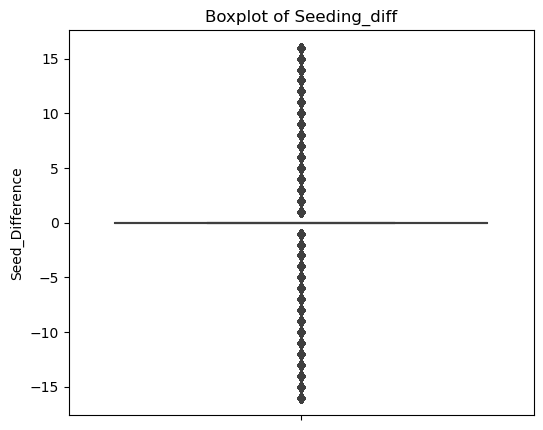

In [39]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["Seed_Difference"])
plt.title("Boxplot of Seeding_diff")
plt.show()

In [40]:

from scipy.stats import pointbiserialr


correlation, p_value = pointbiserialr(m_combined_data["Seed_Difference"], m_combined_data["Results"])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial Correlation: 0.3383
P-value: 0.0000


In [41]:
#offensive and defensive rebounds and total rebound %

m_combined_data["W_OReb%"] = (m_combined_data["WOR"] / 
                                    (m_combined_data["WOR"] + m_combined_data["LDR"])) * 100

m_combined_data["L_OReb%"] = (m_combined_data["LOR"] / 
                                    (m_combined_data["LOR"] + m_combined_data["WDR"])) * 100




In [42]:
# DReb%
m_combined_data["W_DReb%"] = (m_combined_data["WDR"] / 
                                    (m_combined_data["WDR"] + m_combined_data["LOR"])) * 100

m_combined_data["L_DReb%"] = (m_combined_data["LDR"] / 
                                    (m_combined_data["LDR"] + m_combined_data["WOR"])) * 100


In [43]:

m_combined_data["W_Reb%"] = ((m_combined_data["WOR"] + m_combined_data["WDR"]) / 
                                   (m_combined_data["WOR"] + m_combined_data["WDR"] + 
                                    m_combined_data["LOR"] + m_combined_data["LDR"])) * 100

m_combined_data["L_Reb%"] = ((m_combined_data["LOR"] + m_combined_data["LDR"]) / 
                                   (m_combined_data["WOR"] + m_combined_data["WDR"] + 
                                    m_combined_data["LOR"] + m_combined_data["LDR"])) * 100

In [44]:

m_combined_data["Lower_ID_Reb%"] = m_combined_data["W_Reb%"].where(
    m_combined_data["Lower_ID"] == m_combined_data["WTeamID"], m_combined_data["L_Reb%"]
)

m_combined_data["Higher_ID_Reb%"] = m_combined_data["W_Reb%"].where(
    m_combined_data["Higher_ID"] == m_combined_data["WTeamID"],   m_combined_data["L_Reb%"]
)

In [45]:
m_combined_data["Reb%_diff"]= m_combined_data["Lower_ID_Reb%"]-m_combined_data["Higher_ID_Reb%"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,Seed_Difference,W_OReb%,L_OReb%,W_DReb%,L_DReb%,W_Reb%,L_Reb%,Lower_ID_Reb%,Higher_ID_Reb%,Reb%_diff
0,2003,10,1104,68,1328,62,N,0,27,58,...,-9.0,38.888889,29.411765,70.588235,61.111111,54.285714,45.714286,54.285714,45.714286,8.571429
1,2003,10,1272,70,1393,63,N,0,26,62,...,-4.0,37.500000,41.666667,58.333333,62.500000,48.863636,51.136364,48.863636,51.136364,-2.272727
2,2003,11,1266,73,1437,61,N,0,24,58,...,14.0,43.589744,54.385965,45.614035,56.410256,44.791667,55.208333,44.791667,55.208333,-10.416667
3,2003,11,1296,56,1457,50,N,0,18,38,...,0.0,23.076923,47.222222,52.777778,76.923077,40.322581,59.677419,40.322581,59.677419,-19.354839
4,2003,11,1400,77,1208,71,N,0,30,61,...,-16.0,53.125000,48.837209,51.162791,46.875000,52.000000,48.000000,48.000000,52.000000,-4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,7.0,22.857143,27.027027,72.972973,77.142857,48.611111,51.388889,51.388889,48.611111,2.777778
118101,2024,146,1345,72,1397,66,N,0,24,53,...,1.0,32.000000,15.789474,84.210526,68.000000,63.492063,36.507937,63.492063,36.507937,26.984127
118102,2024,152,1163,86,1104,72,N,0,31,62,...,-3.0,32.258065,21.875000,78.125000,67.741935,55.555556,44.444444,44.444444,55.555556,-11.111111
118103,2024,152,1345,63,1301,50,N,0,22,55,...,-10.0,31.250000,17.647059,82.352941,68.750000,57.575758,42.424242,42.424242,57.575758,-15.151515


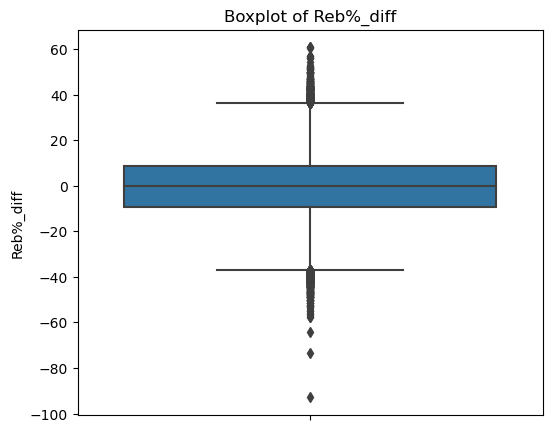

In [46]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["Reb%_diff"])
plt.title("Boxplot of Reb%_diff")
plt.show()

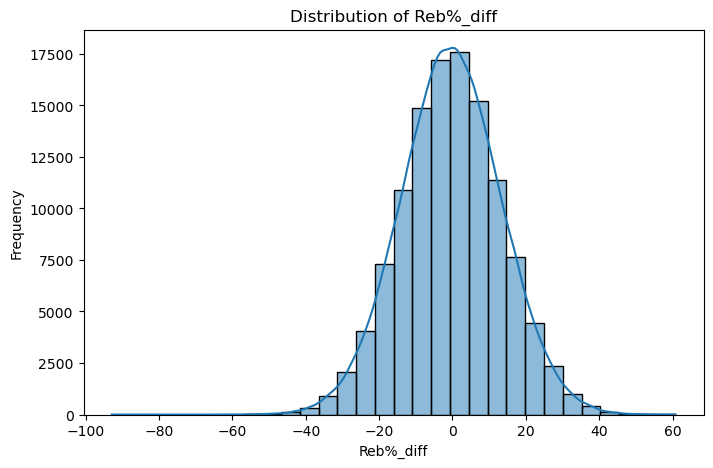

In [47]:

plt.figure(figsize=(8,5))
sns.histplot(m_combined_data["Reb%_diff"], bins=30, kde=True)
plt.title("Distribution of Reb%_diff")
plt.xlabel("Reb%_diff")
plt.ylabel("Frequency")
plt.show()

In [48]:
print(m_combined_data["Reb%_diff"].skew())

-0.001544742577767575


In [49]:
inf_rows_Reb = m_combined_data[np.isinf(m_combined_data["Reb%_diff"])]
inf_rows_Reb

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,Seed_Difference,W_OReb%,L_OReb%,W_DReb%,L_DReb%,W_Reb%,L_Reb%,Lower_ID_Reb%,Higher_ID_Reb%,Reb%_diff


In [50]:
Q1 = m_combined_data["Reb%_diff"].quantile(0.25)
Q3 = m_combined_data["Reb%_diff"].quantile(0.75)
IQR_Reb = Q3 - Q1


lower_bound_iqr_rb = Q1 - 1.5 * IQR_Reb
upper_bound_iqr_rb = Q3 + 1.5 * IQR_Reb


outliers_below_iqr_rb = (m_combined_data["Reb%_diff"] < lower_bound_iqr_rb).sum()
outliers_above_iqr_rb = (m_combined_data["Reb%_diff"] > upper_bound_iqr_rb).sum()

In [51]:
outliers_below_iqr_rb

489

In [52]:
outliers_above_iqr_rb

482

In [53]:
m_combined_data["Reb%_diff"] = np.clip(m_combined_data["Reb%_diff"], lower_bound_iqr_rb, upper_bound_iqr_rb)

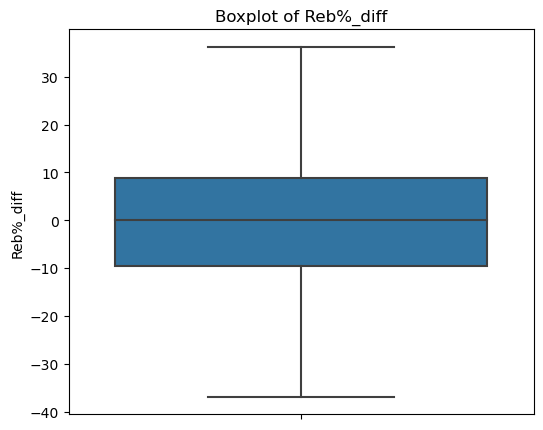

In [54]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["Reb%_diff"])
plt.title("Boxplot of Reb%_diff")
plt.show()

In [55]:

from scipy.stats import pointbiserialr


correlation, p_value = pointbiserialr(m_combined_data["Reb%_diff"], m_combined_data["Results"])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial Correlation: 0.4249
P-value: 0.0000


In [56]:

m_combined_data["W_FTR%"] = (m_combined_data["WFTA"] / m_combined_data["WFGA"]) * 100
m_combined_data["L_FTR%"] = (m_combined_data["LFTA"] / m_combined_data["LFGA"]) * 100


m_combined_data["Lower_ID_FTR%"] = m_combined_data["W_FTR%"].where(
    m_combined_data["Lower_ID"] == m_combined_data["WTeamID"], m_combined_data["L_FTR%"]
)

m_combined_data["Higher_ID_FTR%"] = m_combined_data["W_FTR%"].where(
    m_combined_data["Higher_ID"] == m_combined_data["WTeamID"], m_combined_data["L_FTR%"]
)

In [57]:
m_combined_data["FTR%_diff"]=m_combined_data["Lower_ID_FTR%"]-m_combined_data["Higher_ID_FTR%"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,W_Reb%,L_Reb%,Lower_ID_Reb%,Higher_ID_Reb%,Reb%_diff,W_FTR%,L_FTR%,Lower_ID_FTR%,Higher_ID_FTR%,FTR%_diff
0,2003,10,1104,68,1328,62,N,0,27,58,...,54.285714,45.714286,54.285714,45.714286,8.571429,31.034483,41.509434,31.034483,41.509434,-10.474951
1,2003,10,1272,70,1393,63,N,0,26,62,...,48.863636,51.136364,48.863636,51.136364,-2.272727,30.645161,29.850746,30.645161,29.850746,0.794415
2,2003,11,1266,73,1437,61,N,0,24,58,...,44.791667,55.208333,44.791667,55.208333,-10.416667,50.000000,31.506849,50.000000,31.506849,18.493151
3,2003,11,1296,56,1457,50,N,0,18,38,...,40.322581,59.677419,40.322581,59.677419,-19.354839,81.578947,30.612245,81.578947,30.612245,50.966702
4,2003,11,1400,77,1208,71,N,0,30,61,...,52.000000,48.000000,48.000000,52.000000,-4.000000,21.311475,43.548387,43.548387,21.311475,22.236912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,48.611111,51.388889,51.388889,48.611111,2.777778,38.333333,44.067797,44.067797,38.333333,5.734463
118101,2024,146,1345,72,1397,66,N,0,24,53,...,63.492063,36.507937,63.492063,36.507937,26.984127,62.264151,17.741935,62.264151,17.741935,44.522215
118102,2024,152,1163,86,1104,72,N,0,31,62,...,55.555556,44.444444,44.444444,55.555556,-11.111111,29.032258,18.965517,18.965517,29.032258,-10.066741
118103,2024,152,1345,63,1301,50,N,0,22,55,...,57.575758,42.424242,42.424242,57.575758,-15.151515,18.181818,7.017544,7.017544,18.181818,-11.164274


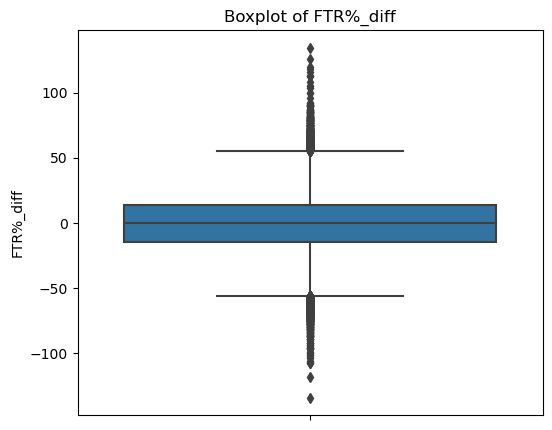

In [58]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["FTR%_diff"])
plt.title("Boxplot of FTR%_diff")
plt.show()

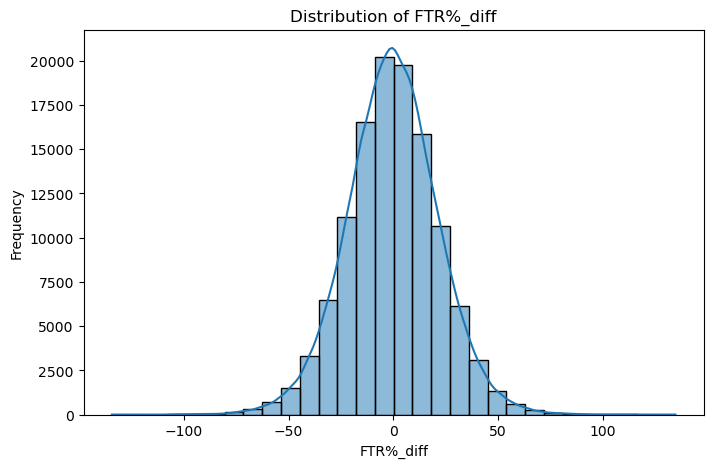

In [59]:
# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(m_combined_data["FTR%_diff"], bins=30, kde=True)
plt.title("Distribution of FTR%_diff")
plt.xlabel("FTR%_diff")
plt.ylabel("Frequency")
plt.show()

In [60]:
Q1 = m_combined_data["FTR%_diff"].quantile(0.25)
Q3 = m_combined_data["FTR%_diff"].quantile(0.75)
IQR_FTR = Q3 - Q1

lower_bound_iqr_ftr = Q1 - 1.5 * IQR_FTR
upper_bound_iqr_ftr = Q3 + 1.5 * IQR_FTR


outliers_below_iqr_ftr = (m_combined_data["FTR%_diff"] < lower_bound_iqr_ftr).sum()
outliers_above_iqr_ftr = (m_combined_data["FTR%_diff"] > upper_bound_iqr_ftr).sum()

In [61]:
outliers_below_iqr_ftr

916

In [62]:
outliers_above_iqr_ftr

893

In [63]:
m_combined_data["FTR%_diff"] = np.clip(m_combined_data["FTR%_diff"], lower_bound_iqr_ftr, upper_bound_iqr_ftr)

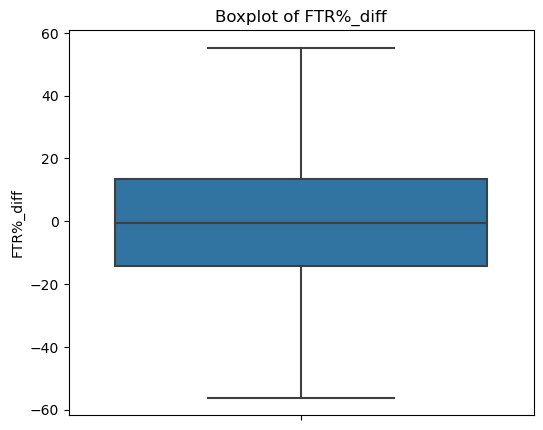

In [64]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["FTR%_diff"])
plt.title("Boxplot of FTR%_diff")
plt.show()

In [65]:
inf_rows_ts = m_combined_data[np.isinf(m_combined_data["FTR%_diff"])]
inf_rows_ts

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,W_Reb%,L_Reb%,Lower_ID_Reb%,Higher_ID_Reb%,Reb%_diff,W_FTR%,L_FTR%,Lower_ID_FTR%,Higher_ID_FTR%,FTR%_diff


In [66]:
m_combined_data["FTR%_diff"].isnull().sum()

1

In [67]:
print(m_combined_data[m_combined_data["FTR%_diff"].isna()])

        Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  \
118094    2024     144     1181      54     1222      51    N      0     0   

        WFGA  ...    W_Reb%     L_Reb%  Lower_ID_Reb%  Higher_ID_Reb%  \
118094     0  ...  3.571429  96.428571       3.571429       96.428571   

        Reb%_diff  W_FTR%     L_FTR%  Lower_ID_FTR%  Higher_ID_FTR%  FTR%_diff  
118094 -36.967419     NaN  34.693878            NaN       34.693878        NaN  

[1 rows x 60 columns]


In [68]:

m_combined_data["W_eFG%"] = ((m_combined_data["WFGM"] + 0.5 * m_combined_data["WFGM3"]) / 
                                  m_combined_data["WFGA"]) * 100

m_combined_data["L_eFG%"] = ((m_combined_data["LFGM"] + 0.5 *m_combined_data["LFGM3"]) / 
                                   m_combined_data["LFGA"]) * 100


m_combined_data["Lower_ID_eFG%"] = m_combined_data["W_eFG%"].where(
    m_combined_data["Lower_ID"] == m_combined_data["WTeamID"], m_combined_data["L_eFG%"]
)

m_combined_data["Higher_ID_eFG%"] = m_combined_data["W_eFG%"].where(
    m_combined_data["Higher_ID"] == m_combined_data["WTeamID"], m_combined_data["L_eFG%"]
)
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,Reb%_diff,W_FTR%,L_FTR%,Lower_ID_FTR%,Higher_ID_FTR%,FTR%_diff,W_eFG%,L_eFG%,Lower_ID_eFG%,Higher_ID_eFG%
0,2003,10,1104,68,1328,62,N,0,27,58,...,8.571429,31.034483,41.509434,31.034483,41.509434,-10.474951,49.137931,43.396226,49.137931,43.396226
1,2003,10,1272,70,1393,63,N,0,26,62,...,-2.272727,30.645161,29.850746,30.645161,29.850746,0.794415,48.387097,40.298507,48.387097,40.298507
2,2003,11,1266,73,1437,61,N,0,24,58,...,-10.416667,50.000000,31.506849,50.000000,31.506849,18.493151,48.275862,32.191781,48.275862,32.191781
3,2003,11,1296,56,1457,50,N,0,18,38,...,-19.354839,81.578947,30.612245,81.578947,30.612245,50.966702,51.315789,42.857143,51.315789,42.857143
4,2003,11,1400,77,1208,71,N,0,30,61,...,-4.000000,21.311475,43.548387,43.548387,21.311475,22.236912,54.098361,43.548387,43.548387,54.098361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,2.777778,38.333333,44.067797,44.067797,38.333333,5.734463,49.166667,36.440678,36.440678,49.166667
118101,2024,146,1345,72,1397,66,N,0,24,53,...,26.984127,62.264151,17.741935,62.264151,17.741935,44.522215,48.113208,47.580645,48.113208,47.580645
118102,2024,152,1163,86,1104,72,N,0,31,62,...,-11.111111,29.032258,18.965517,18.965517,29.032258,-10.066741,58.064516,54.310345,54.310345,58.064516
118103,2024,152,1345,63,1301,50,N,0,22,55,...,-15.151515,18.181818,7.017544,7.017544,18.181818,-11.164274,49.090909,41.228070,41.228070,49.090909


In [69]:
# TOV%
m_combined_data["W_TOV%"] = (m_combined_data["WTO"] / 
                                   (m_combined_data["WFGA"] + 0.44 * m_combined_data["WFTA"] + 
                                    m_combined_data["WTO"])) * 100

m_combined_data["L_TOV%"] = (m_combined_data["LTO"] / 
                                   (m_combined_data["LFGA"] + 0.44 * m_combined_data["LFTA"] + 
                                    m_combined_data["LTO"])) * 100


m_combined_data["Lower_ID_TOV%"] = m_combined_data["W_TOV%"].where(
    m_combined_data["Lower_ID"] == m_combined_data["WTeamID"], m_combined_data["L_TOV%"]
)

m_combined_data["Higher_ID_TOV%"] = m_combined_data["W_TOV%"].where(
    m_combined_data["Higher_ID"] == m_combined_data["WTeamID"], m_combined_data["L_TOV%"]
)
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,Higher_ID_FTR%,FTR%_diff,W_eFG%,L_eFG%,Lower_ID_eFG%,Higher_ID_eFG%,W_TOV%,L_TOV%,Lower_ID_TOV%,Higher_ID_TOV%
0,2003,10,1104,68,1328,62,N,0,27,58,...,41.509434,-10.474951,49.137931,43.396226,49.137931,43.396226,25.865947,22.310362,25.865947,22.310362
1,2003,10,1272,70,1393,63,N,0,26,62,...,29.850746,0.794415,48.387097,40.298507,48.387097,40.298507,15.595010,13.667426,15.595010,13.667426
2,2003,11,1266,73,1437,61,N,0,24,58,...,31.506849,18.493151,48.275862,32.191781,48.275862,32.191781,12.382368,12.615643,12.382368,12.615643
3,2003,11,1296,56,1457,50,N,0,18,38,...,30.612245,50.966702,51.315789,42.857143,51.315789,42.857143,18.856065,25.469169,18.856065,25.469169
4,2003,11,1400,77,1208,71,N,0,30,61,...,21.311475,22.236912,54.098361,43.548387,43.548387,54.098361,17.343905,11.921793,11.921793,17.343905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,38.333333,5.734463,49.166667,36.440678,36.440678,49.166667,5.396654,11.329305,11.329305,5.396654
118101,2024,146,1345,72,1397,66,N,0,24,53,...,17.741935,44.522215,48.113208,47.580645,48.113208,47.580645,12.899897,8.237232,12.899897,8.237232
118102,2024,152,1163,86,1104,72,N,0,31,62,...,29.032258,-10.066741,58.064516,54.310345,54.310345,58.064516,5.411255,10.022910,10.022910,5.411255
118103,2024,152,1345,63,1301,50,N,0,22,55,...,18.181818,-11.164274,49.090909,41.228070,41.228070,49.090909,19.073569,15.768349,15.768349,19.073569


In [70]:
m_combined_data["Lower_ID_Off_Eff"] = m_combined_data["Lower_ID_eFG%"] / m_combined_data["Lower_ID_TOV%"]
m_combined_data["Higher_ID_Off_Eff"] = m_combined_data["Higher_ID_eFG%"] / m_combined_data["Higher_ID_TOV%"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,W_eFG%,L_eFG%,Lower_ID_eFG%,Higher_ID_eFG%,W_TOV%,L_TOV%,Lower_ID_TOV%,Higher_ID_TOV%,Lower_ID_Off_Eff,Higher_ID_Off_Eff
0,2003,10,1104,68,1328,62,N,0,27,58,...,49.137931,43.396226,49.137931,43.396226,25.865947,22.310362,25.865947,22.310362,1.899715,1.945115
1,2003,10,1272,70,1393,63,N,0,26,62,...,48.387097,40.298507,48.387097,40.298507,15.595010,13.667426,15.595010,13.667426,3.102730,2.948507
2,2003,11,1266,73,1437,61,N,0,24,58,...,48.275862,32.191781,48.275862,32.191781,12.382368,12.615643,12.382368,12.615643,3.898759,2.551735
3,2003,11,1296,56,1457,50,N,0,18,38,...,51.315789,42.857143,51.315789,42.857143,18.856065,25.469169,18.856065,25.469169,2.721447,1.682707
4,2003,11,1400,77,1208,71,N,0,30,61,...,54.098361,43.548387,43.548387,54.098361,17.343905,11.921793,11.921793,17.343905,3.652839,3.119157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,49.166667,36.440678,36.440678,49.166667,5.396654,11.329305,11.329305,5.396654,3.216497,9.110583
118101,2024,146,1345,72,1397,66,N,0,24,53,...,48.113208,47.580645,48.113208,47.580645,12.899897,8.237232,12.899897,8.237232,3.729736,5.776290
118102,2024,152,1163,86,1104,72,N,0,31,62,...,58.064516,54.310345,54.310345,58.064516,5.411255,10.022910,10.022910,5.411255,5.418621,10.730323
118103,2024,152,1345,63,1301,50,N,0,22,55,...,49.090909,41.228070,41.228070,49.090909,19.073569,15.768349,15.768349,19.073569,2.614609,2.573766


In [71]:
m_combined_data["off_eff_diff"]=m_combined_data["Lower_ID_Off_Eff"]-m_combined_data["Higher_ID_Off_Eff"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,L_eFG%,Lower_ID_eFG%,Higher_ID_eFG%,W_TOV%,L_TOV%,Lower_ID_TOV%,Higher_ID_TOV%,Lower_ID_Off_Eff,Higher_ID_Off_Eff,off_eff_diff
0,2003,10,1104,68,1328,62,N,0,27,58,...,43.396226,49.137931,43.396226,25.865947,22.310362,25.865947,22.310362,1.899715,1.945115,-0.045400
1,2003,10,1272,70,1393,63,N,0,26,62,...,40.298507,48.387097,40.298507,15.595010,13.667426,15.595010,13.667426,3.102730,2.948507,0.154222
2,2003,11,1266,73,1437,61,N,0,24,58,...,32.191781,48.275862,32.191781,12.382368,12.615643,12.382368,12.615643,3.898759,2.551735,1.347023
3,2003,11,1296,56,1457,50,N,0,18,38,...,42.857143,51.315789,42.857143,18.856065,25.469169,18.856065,25.469169,2.721447,1.682707,1.038741
4,2003,11,1400,77,1208,71,N,0,30,61,...,43.548387,43.548387,54.098361,17.343905,11.921793,11.921793,17.343905,3.652839,3.119157,0.533682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,36.440678,36.440678,49.166667,5.396654,11.329305,11.329305,5.396654,3.216497,9.110583,-5.894086
118101,2024,146,1345,72,1397,66,N,0,24,53,...,47.580645,48.113208,47.580645,12.899897,8.237232,12.899897,8.237232,3.729736,5.776290,-2.046554
118102,2024,152,1163,86,1104,72,N,0,31,62,...,54.310345,54.310345,58.064516,5.411255,10.022910,10.022910,5.411255,5.418621,10.730323,-5.311702
118103,2024,152,1345,63,1301,50,N,0,22,55,...,41.228070,41.228070,49.090909,19.073569,15.768349,15.768349,19.073569,2.614609,2.573766,0.040843


C:\Users\aksha\anaconda3\Lib\site-packages\numpy\core\_methods.py:181: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


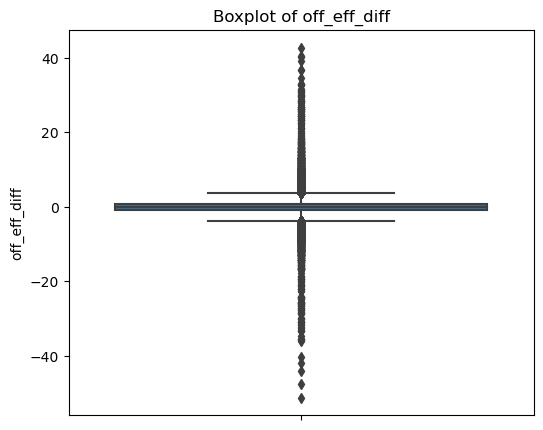

In [72]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["off_eff_diff"])
plt.title("Boxplot of off_eff_diff")
plt.show()

In [73]:
m_combined_data["efg_diff"]=m_combined_data["Lower_ID_eFG%"]-m_combined_data["Higher_ID_eFG%"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,Lower_ID_eFG%,Higher_ID_eFG%,W_TOV%,L_TOV%,Lower_ID_TOV%,Higher_ID_TOV%,Lower_ID_Off_Eff,Higher_ID_Off_Eff,off_eff_diff,efg_diff
0,2003,10,1104,68,1328,62,N,0,27,58,...,49.137931,43.396226,25.865947,22.310362,25.865947,22.310362,1.899715,1.945115,-0.045400,5.741705
1,2003,10,1272,70,1393,63,N,0,26,62,...,48.387097,40.298507,15.595010,13.667426,15.595010,13.667426,3.102730,2.948507,0.154222,8.088589
2,2003,11,1266,73,1437,61,N,0,24,58,...,48.275862,32.191781,12.382368,12.615643,12.382368,12.615643,3.898759,2.551735,1.347023,16.084081
3,2003,11,1296,56,1457,50,N,0,18,38,...,51.315789,42.857143,18.856065,25.469169,18.856065,25.469169,2.721447,1.682707,1.038741,8.458647
4,2003,11,1400,77,1208,71,N,0,30,61,...,43.548387,54.098361,17.343905,11.921793,11.921793,17.343905,3.652839,3.119157,0.533682,-10.549974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,36.440678,49.166667,5.396654,11.329305,11.329305,5.396654,3.216497,9.110583,-5.894086,-12.725989
118101,2024,146,1345,72,1397,66,N,0,24,53,...,48.113208,47.580645,12.899897,8.237232,12.899897,8.237232,3.729736,5.776290,-2.046554,0.532562
118102,2024,152,1163,86,1104,72,N,0,31,62,...,54.310345,58.064516,5.411255,10.022910,10.022910,5.411255,5.418621,10.730323,-5.311702,-3.754171
118103,2024,152,1345,63,1301,50,N,0,22,55,...,41.228070,49.090909,19.073569,15.768349,15.768349,19.073569,2.614609,2.573766,0.040843,-7.862839


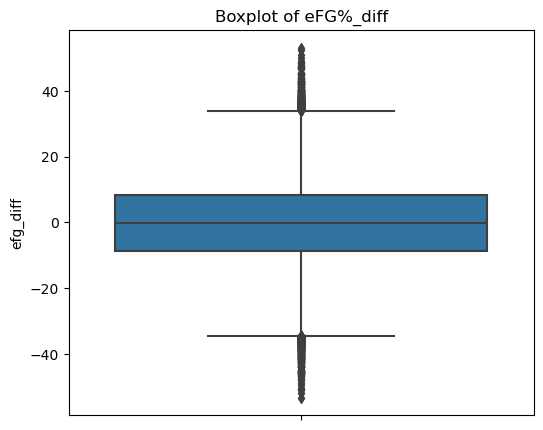

In [74]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["efg_diff"])
plt.title("Boxplot of eFG%_diff")
plt.show()

In [75]:
m_combined_data["tov%_diff"]=m_combined_data["Lower_ID_TOV%"]-m_combined_data["Higher_ID_TOV%"]
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,Higher_ID_eFG%,W_TOV%,L_TOV%,Lower_ID_TOV%,Higher_ID_TOV%,Lower_ID_Off_Eff,Higher_ID_Off_Eff,off_eff_diff,efg_diff,tov%_diff
0,2003,10,1104,68,1328,62,N,0,27,58,...,43.396226,25.865947,22.310362,25.865947,22.310362,1.899715,1.945115,-0.045400,5.741705,3.555585
1,2003,10,1272,70,1393,63,N,0,26,62,...,40.298507,15.595010,13.667426,15.595010,13.667426,3.102730,2.948507,0.154222,8.088589,1.927584
2,2003,11,1266,73,1437,61,N,0,24,58,...,32.191781,12.382368,12.615643,12.382368,12.615643,3.898759,2.551735,1.347023,16.084081,-0.233276
3,2003,11,1296,56,1457,50,N,0,18,38,...,42.857143,18.856065,25.469169,18.856065,25.469169,2.721447,1.682707,1.038741,8.458647,-6.613104
4,2003,11,1400,77,1208,71,N,0,30,61,...,54.098361,17.343905,11.921793,11.921793,17.343905,3.652839,3.119157,0.533682,-10.549974,-5.422112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,2024,146,1301,76,1181,64,N,0,28,60,...,49.166667,5.396654,11.329305,11.329305,5.396654,3.216497,9.110583,-5.894086,-12.725989,5.932651
118101,2024,146,1345,72,1397,66,N,0,24,53,...,47.580645,12.899897,8.237232,12.899897,8.237232,3.729736,5.776290,-2.046554,0.532562,4.662665
118102,2024,152,1163,86,1104,72,N,0,31,62,...,58.064516,5.411255,10.022910,10.022910,5.411255,5.418621,10.730323,-5.311702,-3.754171,4.611654
118103,2024,152,1345,63,1301,50,N,0,22,55,...,49.090909,19.073569,15.768349,15.768349,19.073569,2.614609,2.573766,0.040843,-7.862839,-3.305221


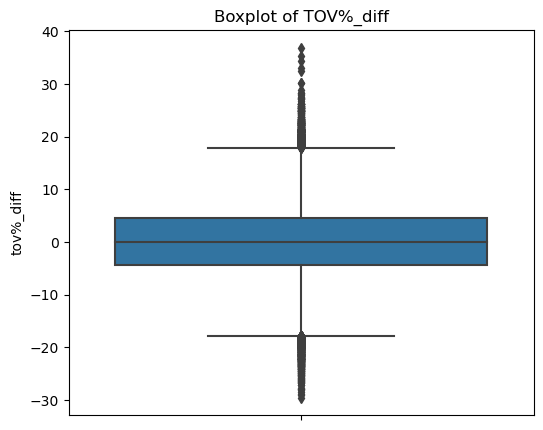

In [76]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["tov%_diff"])
plt.title("Boxplot of TOV%_diff")
plt.show()

In [77]:
inf_rows_ts = m_combined_data[np.isinf(m_combined_data["tov%_diff"])]
inf_rows_ts

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,Higher_ID_eFG%,W_TOV%,L_TOV%,Lower_ID_TOV%,Higher_ID_TOV%,Lower_ID_Off_Eff,Higher_ID_Off_Eff,off_eff_diff,efg_diff,tov%_diff


In [78]:
m_combined_data.isnull().sum()

Season               0
DayNum               0
WTeamID              0
WScore               0
LTeamID              0
                    ..
Lower_ID_Off_Eff     1
Higher_ID_Off_Eff    0
off_eff_diff         1
efg_diff             1
tov%_diff            1
Length: 73, dtype: int64

In [79]:
missing_tov_diff = m_combined_data[m_combined_data["tov%_diff"].isna()]
print(missing_tov_diff)

        Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  \
118094    2024     144     1181      54     1222      51    N      0     0   

        WFGA  ...  Higher_ID_eFG%  W_TOV%     L_TOV%  Lower_ID_TOV%  \
118094     0  ...       42.857143     NaN  15.042118            NaN   

        Higher_ID_TOV%  Lower_ID_Off_Eff  Higher_ID_Off_Eff  off_eff_diff  \
118094       15.042118               NaN           2.849143           NaN   

        efg_diff  tov%_diff  
118094       NaN        NaN  

[1 rows x 73 columns]


In [80]:
missing_tov_diff = m_combined_data[m_combined_data["efg_diff"].isna()]
print(missing_tov_diff)

        Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  \
118094    2024     144     1181      54     1222      51    N      0     0   

        WFGA  ...  Higher_ID_eFG%  W_TOV%     L_TOV%  Lower_ID_TOV%  \
118094     0  ...       42.857143     NaN  15.042118            NaN   

        Higher_ID_TOV%  Lower_ID_Off_Eff  Higher_ID_Off_Eff  off_eff_diff  \
118094       15.042118               NaN           2.849143           NaN   

        efg_diff  tov%_diff  
118094       NaN        NaN  

[1 rows x 73 columns]


In [81]:
missing_tov_diff = m_combined_data[m_combined_data["off_eff_diff"].isna()]
print(missing_tov_diff)

        Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  \
118094    2024     144     1181      54     1222      51    N      0     0   

        WFGA  ...  Higher_ID_eFG%  W_TOV%     L_TOV%  Lower_ID_TOV%  \
118094     0  ...       42.857143     NaN  15.042118            NaN   

        Higher_ID_TOV%  Lower_ID_Off_Eff  Higher_ID_Off_Eff  off_eff_diff  \
118094       15.042118               NaN           2.849143           NaN   

        efg_diff  tov%_diff  
118094       NaN        NaN  

[1 rows x 73 columns]


In [82]:
m_combined_data = m_combined_data.dropna(subset=["tov%_diff"])

In [83]:
missing_tov_diff = m_combined_data[m_combined_data["tov%_diff"].isna()]
print(missing_tov_diff)

Empty DataFrame
Columns: [Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT, WFGM, WFGA, WFGM3, WFGA3, WFTM, WFTA, WOR, WDR, WAst, WTO, WStl, WBlk, WPF, LFGM, LFGA, LFGM3, LFGA3, LFTM, LFTA, LOR, LDR, LAst, LTO, LStl, LBlk, LPF, Lower_ID, Higher_ID, ID, Results, W_TS%, L_TS%, Lower_ID_TS%, Higher_ID_TS%, TS%_diff, Lower_ID_Seed, Higher_ID_Seed, Seed_Difference, W_OReb%, L_OReb%, W_DReb%, L_DReb%, W_Reb%, L_Reb%, Lower_ID_Reb%, Higher_ID_Reb%, Reb%_diff, W_FTR%, L_FTR%, Lower_ID_FTR%, Higher_ID_FTR%, FTR%_diff, W_eFG%, L_eFG%, Lower_ID_eFG%, Higher_ID_eFG%, W_TOV%, L_TOV%, Lower_ID_TOV%, Higher_ID_TOV%, Lower_ID_Off_Eff, Higher_ID_Off_Eff, off_eff_diff, efg_diff, tov%_diff]
Index: []

[0 rows x 73 columns]


In [84]:
missing_tov_diff = m_combined_data[m_combined_data["off_eff_diff"].isna()]
print(missing_tov_diff)

Empty DataFrame
Columns: [Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT, WFGM, WFGA, WFGM3, WFGA3, WFTM, WFTA, WOR, WDR, WAst, WTO, WStl, WBlk, WPF, LFGM, LFGA, LFGM3, LFGA3, LFTM, LFTA, LOR, LDR, LAst, LTO, LStl, LBlk, LPF, Lower_ID, Higher_ID, ID, Results, W_TS%, L_TS%, Lower_ID_TS%, Higher_ID_TS%, TS%_diff, Lower_ID_Seed, Higher_ID_Seed, Seed_Difference, W_OReb%, L_OReb%, W_DReb%, L_DReb%, W_Reb%, L_Reb%, Lower_ID_Reb%, Higher_ID_Reb%, Reb%_diff, W_FTR%, L_FTR%, Lower_ID_FTR%, Higher_ID_FTR%, FTR%_diff, W_eFG%, L_eFG%, Lower_ID_eFG%, Higher_ID_eFG%, W_TOV%, L_TOV%, Lower_ID_TOV%, Higher_ID_TOV%, Lower_ID_Off_Eff, Higher_ID_Off_Eff, off_eff_diff, efg_diff, tov%_diff]
Index: []

[0 rows x 73 columns]


In [85]:

correlation, p_value = pointbiserialr(m_combined_data["tov%_diff"], m_combined_data["Results"])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial Correlation: -0.2221
P-value: 0.0000


In [86]:
correlation, p_value = pointbiserialr(m_combined_data["efg_diff"], m_combined_data["Results"])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial Correlation: 0.6605
P-value: 0.0000


In [87]:

m_combined_data = m_combined_data.copy()


m_combined_data.loc[:, "W_Possessions"] = (
    m_combined_data["WFGA"] - m_combined_data["WOR"] + m_combined_data["WTO"] + (0.44 * m_combined_data["WFTA"])
)

m_combined_data.loc[:, "L_Possessions"] = (
    m_combined_data["LFGA"] - m_combined_data["LOR"] + m_combined_data["LTO"] + (0.44 * m_combined_data["LFTA"])
)


m_combined_data.loc[:, "W_Off_Eff"] = (m_combined_data["WScore"] / m_combined_data["W_Possessions"]) * 100
m_combined_data.loc[:, "L_Off_Eff"] = (m_combined_data["LScore"] / m_combined_data["L_Possessions"]) * 100


m_combined_data.loc[:, "W_Def_Eff"] = m_combined_data["L_Off_Eff"]
m_combined_data.loc[:, "L_Def_Eff"] = m_combined_data["W_Off_Eff"]


m_combined_data.loc[:, "W_Net_Eff"] = m_combined_data["W_Off_Eff"] - m_combined_data["W_Def_Eff"]
m_combined_data.loc[:, "L_Net_Eff"] = m_combined_data["L_Off_Eff"] - m_combined_data["L_Def_Eff"]


m_combined_data.loc[:, "Lower_ID"] = m_combined_data[["WTeamID", "LTeamID"]].min(axis=1)
m_combined_data.loc[:, "Higher_ID"] = m_combined_data[["WTeamID", "LTeamID"]].max(axis=1)


m_combined_data.loc[:, "Lower_ID_Off_Eff"] = m_combined_data.apply(
    lambda x: x["W_Off_Eff"] if x["Lower_ID"] == x["WTeamID"] else x["L_Off_Eff"], axis=1
)

m_combined_data.loc[:, "Higher_ID_Off_Eff"] = m_combined_data.apply(
    lambda x: x["W_Off_Eff"] if x["Higher_ID"] == x["WTeamID"] else x["L_Off_Eff"], axis=1
)

m_combined_data.loc[:, "Lower_ID_Def_Eff"] = m_combined_data.apply(
    lambda x: x["W_Def_Eff"] if x["Lower_ID"] == x["WTeamID"] else x["L_Def_Eff"], axis=1
)

m_combined_data.loc[:, "Higher_ID_Def_Eff"] = m_combined_data.apply(
    lambda x: x["W_Def_Eff"] if x["Higher_ID"] == x["WTeamID"] else x["L_Def_Eff"], axis=1
)

m_combined_data.loc[:, "Lower_ID_Net_Eff"] = m_combined_data["Lower_ID_Off_Eff"] - m_combined_data["Lower_ID_Def_Eff"]
m_combined_data.loc[:, "Higher_ID_Net_Eff"] = m_combined_data["Higher_ID_Off_Eff"] - m_combined_data["Higher_ID_Def_Eff"]

m_combined_data.loc[:, "Net_Eff_Diff"] = m_combined_data["Lower_ID_Net_Eff"] - m_combined_data["Higher_ID_Net_Eff"]


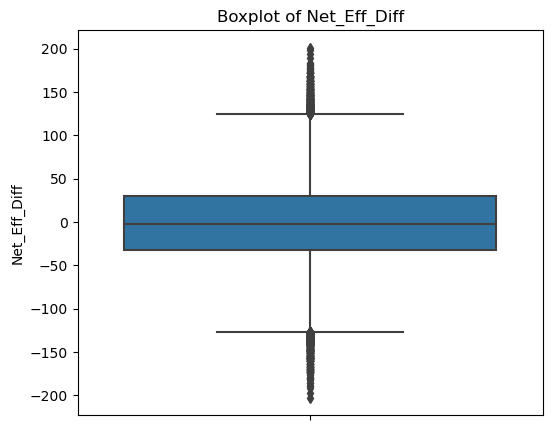

In [88]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["Net_Eff_Diff"])
plt.title("Boxplot of Net_Eff_Diff")
plt.show()

In [89]:
missing_tov_diff = m_combined_data[m_combined_data["Net_Eff_Diff"].isna()]
print(missing_tov_diff)

Empty DataFrame
Columns: [Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT, WFGM, WFGA, WFGM3, WFGA3, WFTM, WFTA, WOR, WDR, WAst, WTO, WStl, WBlk, WPF, LFGM, LFGA, LFGM3, LFGA3, LFTM, LFTA, LOR, LDR, LAst, LTO, LStl, LBlk, LPF, Lower_ID, Higher_ID, ID, Results, W_TS%, L_TS%, Lower_ID_TS%, Higher_ID_TS%, TS%_diff, Lower_ID_Seed, Higher_ID_Seed, Seed_Difference, W_OReb%, L_OReb%, W_DReb%, L_DReb%, W_Reb%, L_Reb%, Lower_ID_Reb%, Higher_ID_Reb%, Reb%_diff, W_FTR%, L_FTR%, Lower_ID_FTR%, Higher_ID_FTR%, FTR%_diff, W_eFG%, L_eFG%, Lower_ID_eFG%, Higher_ID_eFG%, W_TOV%, L_TOV%, Lower_ID_TOV%, Higher_ID_TOV%, Lower_ID_Off_Eff, Higher_ID_Off_Eff, off_eff_diff, efg_diff, tov%_diff, W_Possessions, L_Possessions, W_Off_Eff, L_Off_Eff, W_Def_Eff, L_Def_Eff, W_Net_Eff, L_Net_Eff, Lower_ID_Def_Eff, Higher_ID_Def_Eff, Lower_ID_Net_Eff, Higher_ID_Net_Eff, Net_Eff_Diff]
Index: []

[0 rows x 86 columns]


In [90]:

correlation, p_value = pointbiserialr(m_combined_data["Net_Eff_Diff"], m_combined_data["Results"])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial Correlation: 0.8001
P-value: 0.0000


In [91]:

m_all_games = pd.concat([m_tournament, m_regular], ignore_index=True)


m_all_games["Lower_ID"] = m_all_games[["WTeamID", "LTeamID"]].min(axis=1)
m_all_games["Higher_ID"] = m_all_games[["WTeamID", "LTeamID"]].max(axis=1)


m_all_games["H2H_Win"] = (m_all_games["Lower_ID"] == m_all_games["WTeamID"]).astype(int)


h2h_stats = m_all_games.groupby(["Lower_ID", "Higher_ID"])["H2H_Win"].agg(["sum", "count"]).reset_index()


h2h_stats.rename(columns={"sum": "H2H_Wins", "count": "Total_H2H_Games"}, inplace=True)


h2h_stats["H2H_Win%"] = h2h_stats["H2H_Wins"] / h2h_stats["Total_H2H_Games"]

h2h_stats.loc[h2h_stats["Total_H2H_Games"] == 0, "H2H_Win%"] = "Never Played"


h2h_stats.loc[h2h_stats["Total_H2H_Games"] == 1, "H2H_Win%"] = "Only Played Once"


In [92]:
h2h_stats

,Lower_ID,Higher_ID,H2H_Wins,Total_H2H_Games,H2H_Win%
0,1101,1102,1,1,Only Played Once
1,1101,1115,1,1,Only Played Once
2,1101,1116,0,2,0.0
3,1101,1117,1,2,0.5
4,1101,1122,1,1,Only Played Once
...,...,...,...,...,...
29926,1473,1476,1,1,Only Played Once
29927,1476,1477,1,2,0.5
29928,1476,1478,0,3,0.0
29929,1476,1479,0,1,Only Played Once


In [93]:

never_played_count = (h2h_stats["H2H_Win%"] == "Never Played").sum()


only_played_once_count = (h2h_stats["H2H_Win%"] == "Only Played Once").sum()


print("Teams that have never played before:", never_played_count)
print("Teams that have only played once:", only_played_once_count)

Teams that have never played before: 0
Teams that have only played once: 12186


In [94]:
h2h_stats.drop(columns=["H2H_Win%"], inplace=True)

In [95]:
h2h_stats

,Lower_ID,Higher_ID,H2H_Wins,Total_H2H_Games
0,1101,1102,1,1
1,1101,1115,1,1
2,1101,1116,0,2
3,1101,1117,1,2
4,1101,1122,1,1
...,...,...,...,...
29926,1473,1476,1,1
29927,1476,1477,1,2
29928,1476,1478,0,3
29929,1476,1479,0,1


In [96]:
no_matches=(h2h_stats["Total_H2H_Games"]==0).sum()
no_matches

0

In [97]:
# Set smoothing factor (Laplace Smoothing)
k = 1  

# Combine tournament and regular season data
m_all_games = pd.concat([m_tournament, m_regular], ignore_index=True)

# Assign Lower_ID and Higher_ID for consistency
m_all_games["Lower_ID"] = m_all_games[["WTeamID", "LTeamID"]].min(axis=1)
m_all_games["Higher_ID"] = m_all_games[["WTeamID", "LTeamID"]].max(axis=1)

# Create a Win Indicator (1 if Lower_ID won, 0 if Higher_ID won)
m_all_games["H2H_Win"] = (m_all_games["Lower_ID"] == m_all_games["WTeamID"]).astype(int)

# Aggregate to Compute H2H Statistics
h2h_stats = m_all_games.groupby(["Lower_ID", "Higher_ID"])["H2H_Win"].agg(["sum", "count"]).reset_index()

# Rename columns for clarity
h2h_stats.rename(columns={"sum": "H2H_Wins", "count": "Total_H2H_Games"}, inplace=True)

# Apply Laplace Smoothing to compute Head-to-Head Win Percentage
h2h_stats["H2H_Win%"] = (h2h_stats["H2H_Wins"] + k) / (h2h_stats["Total_H2H_Games"] + 2 * k)

In [98]:
h2h_stats

,Lower_ID,Higher_ID,H2H_Wins,Total_H2H_Games,H2H_Win%
0,1101,1102,1,1,0.666667
1,1101,1115,1,1,0.666667
2,1101,1116,0,2,0.250000
3,1101,1117,1,2,0.500000
4,1101,1122,1,1,0.666667
...,...,...,...,...,...
29926,1473,1476,1,1,0.666667
29927,1476,1477,1,2,0.500000
29928,1476,1478,0,3,0.200000
29929,1476,1479,0,1,0.333333


In [99]:
m_combined_data = m_combined_data.merge(h2h_stats, on=["Lower_ID", "Higher_ID"], how="left")

In [100]:
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,W_Net_Eff,L_Net_Eff,Lower_ID_Def_Eff,Higher_ID_Def_Eff,Lower_ID_Net_Eff,Higher_ID_Net_Eff,Net_Eff_Diff,H2H_Wins,Total_H2H_Games,H2H_Win%
0,2003,10,1104,68,1328,62,N,0,27,58,...,3.044183,-3.044183,87.719298,90.763481,3.044183,-3.044183,6.088366,4,9,0.454545
1,2003,10,1272,70,1393,63,N,0,26,62,...,9.478710,-9.478710,92.920354,102.399064,9.478710,-9.478710,18.957420,1,4,0.333333
2,2003,11,1266,73,1437,61,N,0,24,58,...,19.357721,-19.357721,95.134124,114.491844,19.357721,-19.357721,38.715442,18,40,0.452381
3,2003,11,1296,56,1457,50,N,0,18,38,...,10.349198,-10.349198,86.805556,97.154754,10.349198,-10.349198,20.698396,1,3,0.400000
4,2003,11,1400,77,1208,71,N,0,30,61,...,7.927694,-7.927694,120.841180,112.913486,-7.927694,7.927694,-15.855388,7,11,0.615385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118099,2024,146,1301,76,1181,64,N,0,28,60,...,22.776630,-22.776630,114.942529,92.165899,-22.776630,22.776630,-45.553260,59,83,0.705882
118100,2024,146,1345,72,1397,66,N,0,24,53,...,4.824051,-4.824051,98.743268,103.567319,4.824051,-4.824051,9.648103,4,5,0.714286
118101,2024,152,1163,86,1104,72,N,0,31,62,...,19.966476,-19.966476,134.543179,114.576703,-19.966476,19.966476,-39.932952,0,3,0.200000
118102,2024,152,1345,63,1301,50,N,0,22,55,...,20.950014,-20.950014,99.369085,78.419072,-20.950014,20.950014,-41.900027,2,6,0.375000


In [101]:
m_combined_data.isnull().sum()

Season               0
DayNum               0
WTeamID              0
WScore               0
LTeamID              0
                    ..
Higher_ID_Net_Eff    0
Net_Eff_Diff         0
H2H_Wins             0
Total_H2H_Games      0
H2H_Win%             0
Length: 89, dtype: int64

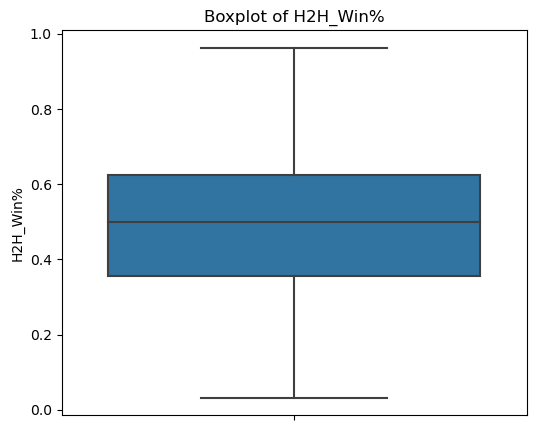

In [102]:
plt.figure(figsize=(6,5))
sns.boxplot(y=m_combined_data["H2H_Win%"])
plt.title("Boxplot of H2H_Win%")
plt.show()

In [103]:

correlation, p_value = pointbiserialr(m_combined_data["H2H_Win%"], m_combined_data["Results"])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Point-Biserial Correlation: 0.4954
P-value: 0.0000


In [104]:
m_combined_data.columns.to_list()

['Season',
 'DayNum',
 'WTeamID',
 'WScore',
 'LTeamID',
 'LScore',
 'WLoc',
 'NumOT',
 'WFGM',
 'WFGA',
 'WFGM3',
 'WFGA3',
 'WFTM',
 'WFTA',
 'WOR',
 'WDR',
 'WAst',
 'WTO',
 'WStl',
 'WBlk',
 'WPF',
 'LFGM',
 'LFGA',
 'LFGM3',
 'LFGA3',
 'LFTM',
 'LFTA',
 'LOR',
 'LDR',
 'LAst',
 'LTO',
 'LStl',
 'LBlk',
 'LPF',
 'Lower_ID',
 'Higher_ID',
 'ID',
 'Results',
 'W_TS%',
 'L_TS%',
 'Lower_ID_TS%',
 'Higher_ID_TS%',
 'TS%_diff',
 'Lower_ID_Seed',
 'Higher_ID_Seed',
 'Seed_Difference',
 'W_OReb%',
 'L_OReb%',
 'W_DReb%',
 'L_DReb%',
 'W_Reb%',
 'L_Reb%',
 'Lower_ID_Reb%',
 'Higher_ID_Reb%',
 'Reb%_diff',
 'W_FTR%',
 'L_FTR%',
 'Lower_ID_FTR%',
 'Higher_ID_FTR%',
 'FTR%_diff',
 'W_eFG%',
 'L_eFG%',
 'Lower_ID_eFG%',
 'Higher_ID_eFG%',
 'W_TOV%',
 'L_TOV%',
 'Lower_ID_TOV%',
 'Higher_ID_TOV%',
 'Lower_ID_Off_Eff',
 'Higher_ID_Off_Eff',
 'off_eff_diff',
 'efg_diff',
 'tov%_diff',
 'W_Possessions',
 'L_Possessions',
 'W_Off_Eff',
 'L_Off_Eff',
 'W_Def_Eff',
 'L_Def_Eff',
 'W_Net_Eff',
 'L_Net

In [105]:

selected_features = ['TS%_diff', 'Net_Eff_Diff', 'Seed_Difference', 
                     'H2H_Win%', 'Reb%_diff', 'efg_diff', 'tov%_diff','Results']

In [106]:
selected_features

['TS%_diff',
 'Net_Eff_Diff',
 'Seed_Difference',
 'H2H_Win%',
 'Reb%_diff',
 'efg_diff',
 'tov%_diff',
 'Results']

In [107]:
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,W_Net_Eff,L_Net_Eff,Lower_ID_Def_Eff,Higher_ID_Def_Eff,Lower_ID_Net_Eff,Higher_ID_Net_Eff,Net_Eff_Diff,H2H_Wins,Total_H2H_Games,H2H_Win%
0,2003,10,1104,68,1328,62,N,0,27,58,...,3.044183,-3.044183,87.719298,90.763481,3.044183,-3.044183,6.088366,4,9,0.454545
1,2003,10,1272,70,1393,63,N,0,26,62,...,9.478710,-9.478710,92.920354,102.399064,9.478710,-9.478710,18.957420,1,4,0.333333
2,2003,11,1266,73,1437,61,N,0,24,58,...,19.357721,-19.357721,95.134124,114.491844,19.357721,-19.357721,38.715442,18,40,0.452381
3,2003,11,1296,56,1457,50,N,0,18,38,...,10.349198,-10.349198,86.805556,97.154754,10.349198,-10.349198,20.698396,1,3,0.400000
4,2003,11,1400,77,1208,71,N,0,30,61,...,7.927694,-7.927694,120.841180,112.913486,-7.927694,7.927694,-15.855388,7,11,0.615385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118099,2024,146,1301,76,1181,64,N,0,28,60,...,22.776630,-22.776630,114.942529,92.165899,-22.776630,22.776630,-45.553260,59,83,0.705882
118100,2024,146,1345,72,1397,66,N,0,24,53,...,4.824051,-4.824051,98.743268,103.567319,4.824051,-4.824051,9.648103,4,5,0.714286
118101,2024,152,1163,86,1104,72,N,0,31,62,...,19.966476,-19.966476,134.543179,114.576703,-19.966476,19.966476,-39.932952,0,3,0.200000
118102,2024,152,1345,63,1301,50,N,0,22,55,...,20.950014,-20.950014,99.369085,78.419072,-20.950014,20.950014,-41.900027,2,6,0.375000


In [108]:

missing_values = m_combined_data[selected_features].isnull().sum()
print("Missing Values in Each Column:\n", missing_values)


nan_values = m_combined_data[selected_features].isna().sum()
print("\nNaN Values in Each Column:\n", nan_values)


def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers.shape[0]

outlier_counts = {col: detect_outliers_iqr(m_combined_data, col) for col in selected_features if m_combined_data[col].dtype != 'object'}
print("\nOutlier Count in Each Numeric Column:\n", outlier_counts)

Missing Values in Each Column:
 TS%_diff           0
Net_Eff_Diff       0
Seed_Difference    0
H2H_Win%           0
Reb%_diff          0
efg_diff           0
tov%_diff          0
Results            0
dtype: int64

NaN Values in Each Column:
 TS%_diff           0
Net_Eff_Diff       0
Seed_Difference    0
H2H_Win%           0
Reb%_diff          0
efg_diff           0
tov%_diff          0
Results            0
dtype: int64

Outlier Count in Each Numeric Column:
 {'TS%_diff': 399, 'Net_Eff_Diff': 926, 'Seed_Difference': 38844, 'H2H_Win%': 0, 'Reb%_diff': 0, 'efg_diff': 758, 'tov%_diff': 1223, 'Results': 0}


Skewness of Features:
 TS%_diff           0.010725
Net_Eff_Diff       0.003839
Seed_Difference    0.078173
H2H_Win%           0.057241
Reb%_diff          0.002689
efg_diff           0.003912
tov%_diff          0.010304
Results            0.053023
dtype: float64


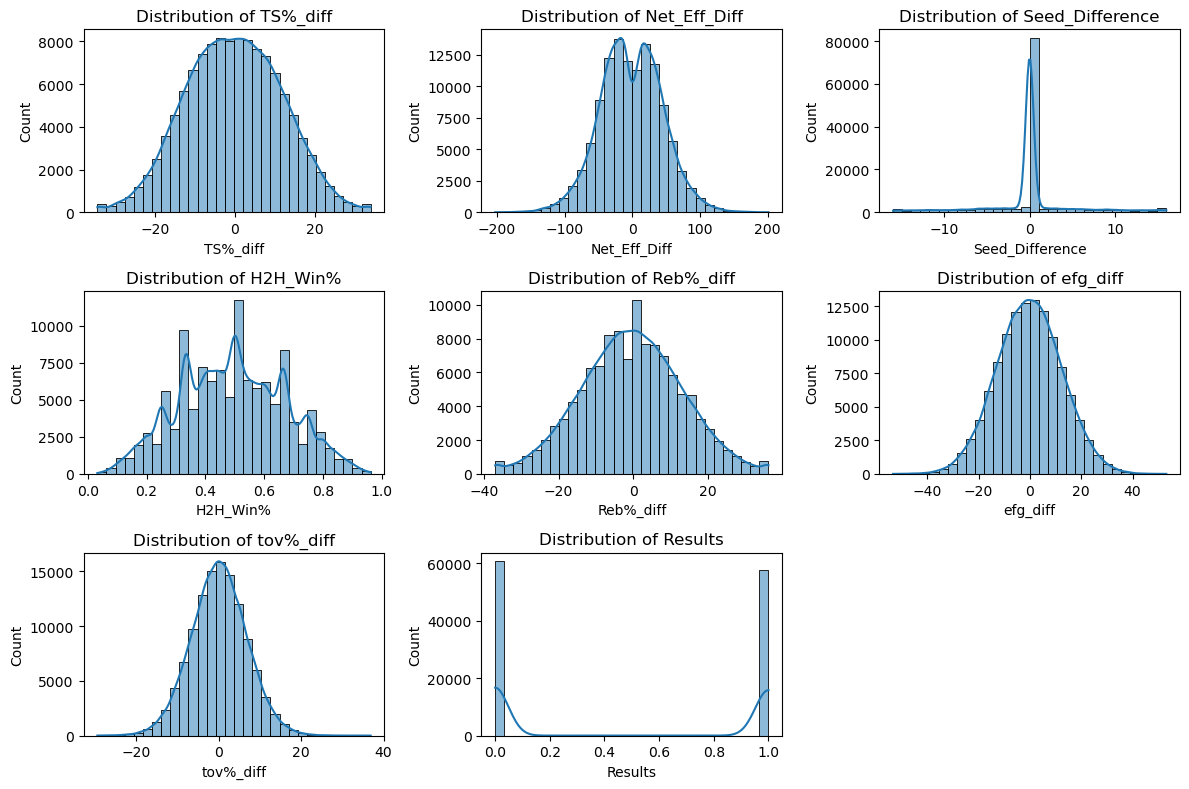

In [109]:

skewness_values = m_combined_data[selected_features].apply(lambda x: skew(x, nan_policy='omit'))
print("Skewness of Features:\n", skewness_values)


plt.figure(figsize=(12, 8))
for i, col in enumerate(selected_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(m_combined_data[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [110]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler




In [111]:

print(m_combined_data[selected_features].isnull().sum())


print(np.isinf(m_combined_data[selected_features]).sum())

TS%_diff           0
Net_Eff_Diff       0
Seed_Difference    0
H2H_Win%           0
Reb%_diff          0
efg_diff           0
tov%_diff          0
Results            0
dtype: int64
TS%_diff           0
Net_Eff_Diff       0
Seed_Difference    0
H2H_Win%           0
Reb%_diff          0
efg_diff           0
tov%_diff          0
Results            0
dtype: int64


Skewness of Features:
 TS%_diff           0.010725
Net_Eff_Diff       0.003839
Seed_Difference    0.078173
H2H_Win%           0.057241
Reb%_diff          0.002689
efg_diff           0.003912
tov%_diff          0.010304
Results            0.053023
dtype: float64


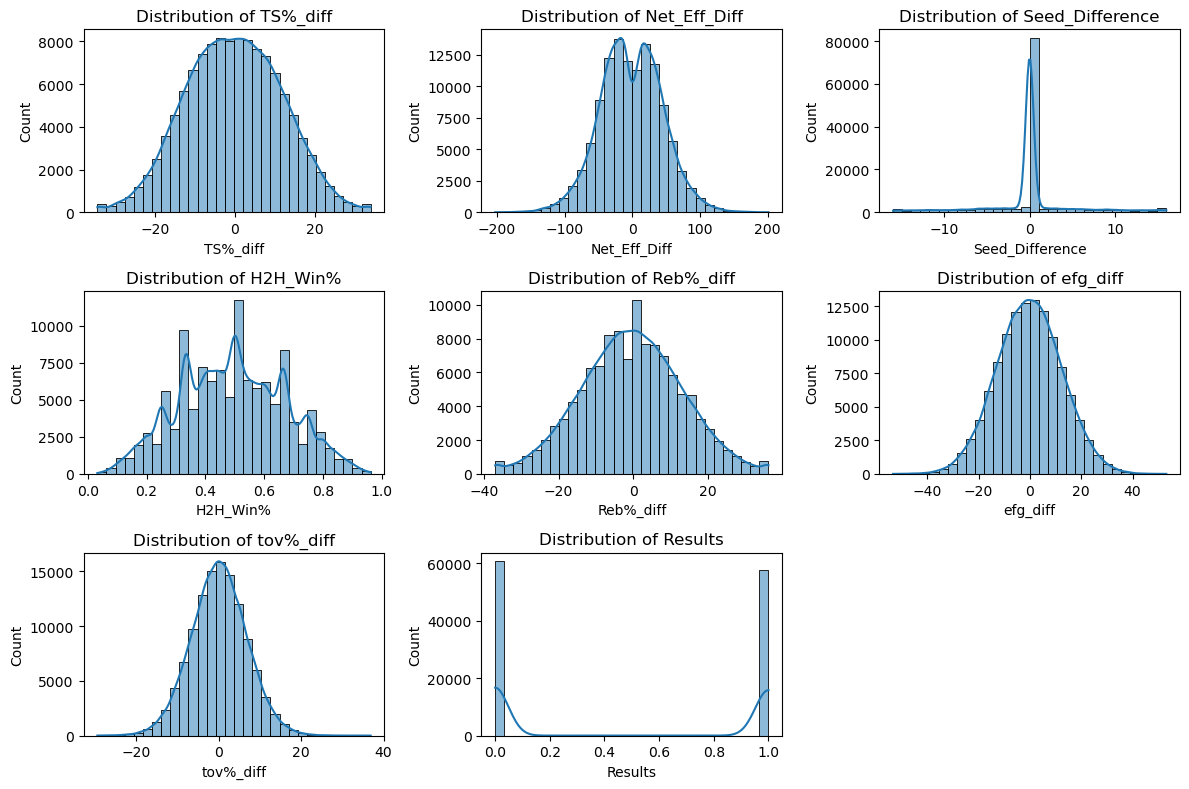

In [112]:
#skewness
skewness_values = m_combined_data[selected_features].apply(lambda x: skew(x, nan_policy='omit'))
print("Skewness of Features:\n", skewness_values)


plt.figure(figsize=(12, 8))
for i, col in enumerate(selected_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(m_combined_data[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [113]:
df_selected = m_combined_data[selected_features]
df_selected

,TS%_diff,Net_Eff_Diff,Seed_Difference,H2H_Win%,Reb%_diff,efg_diff,tov%_diff,Results
0,2.120108,6.088366,-9.0,0.454545,8.571429,5.741705,3.555585,1
1,8.187445,18.957420,-4.0,0.333333,-2.272727,8.088589,1.927584,1
2,14.888879,38.715442,14.0,0.452381,-10.416667,16.084081,-0.233276,1
3,9.257505,20.698396,0.0,0.400000,-19.354839,8.458647,-6.613104,1
4,-9.652944,-15.855388,-16.0,0.615385,-4.000000,-10.549974,-5.422112,0
...,...,...,...,...,...,...,...,...
118099,-8.764079,-45.553260,7.0,0.705882,2.777778,-12.725989,5.932651,0
118100,3.945902,9.648103,1.0,0.714286,26.984127,0.532562,4.662665,1
118101,-4.210504,-39.932952,-3.0,0.200000,-11.111111,-3.754171,4.611654,0
118102,-10.484353,-41.900027,-10.0,0.375000,-15.151515,-7.862839,-3.305221,0


In [114]:
!pip install xgboost
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss


X = df_selected.drop(columns=['Results'])  
y = df_selected['Results'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict_proba(X_test)[:, 1] 
rf_log_loss = log_loss(y_test, y_pred_rf)


xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]  
xgb_log_loss = log_loss(y_test, y_pred_xgb)


print(f"Random Forest Log Loss: {rf_log_loss:.4f}")
print(f"XGBoost Log Loss: {xgb_log_loss:.4f}")

C:\Users\aksha\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:24:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Random Forest Log Loss: 0.1059
XGBoost Log Loss: 0.0745


100%|===================| 23607/23621 [02:17<00:00]        

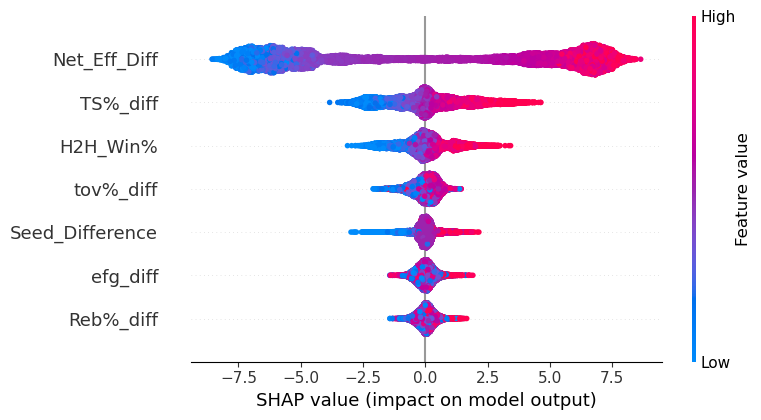

In [115]:
#which features contribute more to prediction
!pip install shap

import shap

explainer = shap.Explainer(xgb_model, X_test)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

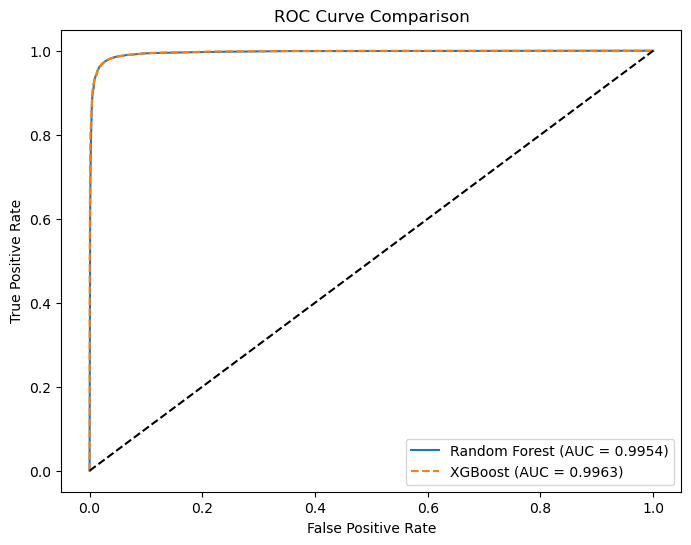

In [116]:

# ROC curve
from sklearn.metrics import roc_curve, auc
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)


auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)


plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linestyle='dashed')
plt.plot([0,1], [0,1], 'k--')  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [117]:

#accuracy
from sklearn.metrics import accuracy_score


y_pred_rf_binary = (y_pred_rf >= 0.5).astype(int)
y_pred_xgb_binary = (y_pred_xgb >= 0.5).astype(int)


rf_accuracy = accuracy_score(y_test, y_pred_rf_binary)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb_binary)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

Random Forest Accuracy: 0.9735
XGBoost Accuracy: 0.9734


In [118]:
# Brier Scores

from sklearn.metrics import brier_score_loss


brier_rf = brier_score_loss(y_test, y_pred_rf)

brier_xgb = brier_score_loss(y_test, y_pred_xgb)


print(f"Random Forest Brier Score: {brier_rf:.4f}")
print(f"XGBoost Brier Score: {brier_xgb:.4f}")

Random Forest Brier Score: 0.0204
XGBoost Brier Score: 0.0205


In [119]:
print(f"Random Forest Probabilities: Min = {y_pred_rf.min():.4f}, Max = {y_pred_rf.max():.4f}")
print(f"XGBoost Probabilities: Min = {y_pred_xgb.min():.4f}, Max = {y_pred_xgb.max():.4f}")

Random Forest Probabilities: Min = 0.0000, Max = 1.0000
XGBoost Probabilities: Min = 0.0000, Max = 1.0000


In [120]:
m_matchups

,Lower_ID,Higher_ID,Season,ID
1,1101,1102,2025,2025_1101_1102
2,1101,1103,2025,2025_1101_1103
3,1101,1104,2025,2025_1101_1104
4,1101,1105,2025,2025_1101_1105
5,1101,1106,2025,2025_1101_1106
...,...,...,...,...
131402,1477,1479,2025,2025_1477_1479
131403,1477,1480,2025,2025_1477_1480
131766,1478,1479,2025,2025_1478_1479
131767,1478,1480,2025,2025_1478_1480


In [121]:
m_combined_data

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,W_Net_Eff,L_Net_Eff,Lower_ID_Def_Eff,Higher_ID_Def_Eff,Lower_ID_Net_Eff,Higher_ID_Net_Eff,Net_Eff_Diff,H2H_Wins,Total_H2H_Games,H2H_Win%
0,2003,10,1104,68,1328,62,N,0,27,58,...,3.044183,-3.044183,87.719298,90.763481,3.044183,-3.044183,6.088366,4,9,0.454545
1,2003,10,1272,70,1393,63,N,0,26,62,...,9.478710,-9.478710,92.920354,102.399064,9.478710,-9.478710,18.957420,1,4,0.333333
2,2003,11,1266,73,1437,61,N,0,24,58,...,19.357721,-19.357721,95.134124,114.491844,19.357721,-19.357721,38.715442,18,40,0.452381
3,2003,11,1296,56,1457,50,N,0,18,38,...,10.349198,-10.349198,86.805556,97.154754,10.349198,-10.349198,20.698396,1,3,0.400000
4,2003,11,1400,77,1208,71,N,0,30,61,...,7.927694,-7.927694,120.841180,112.913486,-7.927694,7.927694,-15.855388,7,11,0.615385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118099,2024,146,1301,76,1181,64,N,0,28,60,...,22.776630,-22.776630,114.942529,92.165899,-22.776630,22.776630,-45.553260,59,83,0.705882
118100,2024,146,1345,72,1397,66,N,0,24,53,...,4.824051,-4.824051,98.743268,103.567319,4.824051,-4.824051,9.648103,4,5,0.714286
118101,2024,152,1163,86,1104,72,N,0,31,62,...,19.966476,-19.966476,134.543179,114.576703,-19.966476,19.966476,-39.932952,0,3,0.200000
118102,2024,152,1345,63,1301,50,N,0,22,55,...,20.950014,-20.950014,99.369085,78.419072,-20.950014,20.950014,-41.900027,2,6,0.375000


In [122]:
m_combined_data.columns.tolist()

['Season',
 'DayNum',
 'WTeamID',
 'WScore',
 'LTeamID',
 'LScore',
 'WLoc',
 'NumOT',
 'WFGM',
 'WFGA',
 'WFGM3',
 'WFGA3',
 'WFTM',
 'WFTA',
 'WOR',
 'WDR',
 'WAst',
 'WTO',
 'WStl',
 'WBlk',
 'WPF',
 'LFGM',
 'LFGA',
 'LFGM3',
 'LFGA3',
 'LFTM',
 'LFTA',
 'LOR',
 'LDR',
 'LAst',
 'LTO',
 'LStl',
 'LBlk',
 'LPF',
 'Lower_ID',
 'Higher_ID',
 'ID',
 'Results',
 'W_TS%',
 'L_TS%',
 'Lower_ID_TS%',
 'Higher_ID_TS%',
 'TS%_diff',
 'Lower_ID_Seed',
 'Higher_ID_Seed',
 'Seed_Difference',
 'W_OReb%',
 'L_OReb%',
 'W_DReb%',
 'L_DReb%',
 'W_Reb%',
 'L_Reb%',
 'Lower_ID_Reb%',
 'Higher_ID_Reb%',
 'Reb%_diff',
 'W_FTR%',
 'L_FTR%',
 'Lower_ID_FTR%',
 'Higher_ID_FTR%',
 'FTR%_diff',
 'W_eFG%',
 'L_eFG%',
 'Lower_ID_eFG%',
 'Higher_ID_eFG%',
 'W_TOV%',
 'L_TOV%',
 'Lower_ID_TOV%',
 'Higher_ID_TOV%',
 'Lower_ID_Off_Eff',
 'Higher_ID_Off_Eff',
 'off_eff_diff',
 'efg_diff',
 'tov%_diff',
 'W_Possessions',
 'L_Possessions',
 'W_Off_Eff',
 'L_Off_Eff',
 'W_Def_Eff',
 'L_Def_Eff',
 'W_Net_Eff',
 'L_Net

In [123]:
features_to_average = [
    "Lower_ID_TS%", "Higher_ID_TS%", "Lower_ID_Reb%", "Higher_ID_Reb%",
    "Lower_ID_FTR%", "Higher_ID_FTR%", "Lower_ID_eFG%", "Higher_ID_eFG%",
    "Lower_ID_TOV%", "Higher_ID_TOV%", "Lower_ID_Off_Eff", "Higher_ID_Off_Eff",
    "Lower_ID_Def_Eff", "Higher_ID_Def_Eff", "Lower_ID_Net_Eff", "Higher_ID_Net_Eff","Lower_ID_Seed","Higher_ID_Seed",
]

In [124]:

# Features to extract (only lower-related ones)
lower_features = ["Lower_ID"] + [col for col in features_to_average if "Lower_" in col]

# Create a separate table for Lower_ID
lower_id_combined = m_combined_data[["Season", "DayNum"] + lower_features].copy()

# Rename columns (optional, for clarity)
lower_id_combined = lower_id_combined.rename(columns={"Lower_ID": "Team_ID"})

lower_id_combined.rename(columns=lambda x: x.replace('Lower_ID_', '') if 'Lower_ID_' in x else x, inplace=True)

In [125]:
lower_id_combined

,Season,DayNum,Team_ID,TS%,Reb%,FTR%,eFG%,TOV%,Off_Eff,Def_Eff,Net_Eff,Seed
0,2003,10,1104,51.577670,54.285714,31.034483,49.137931,25.865947,90.763481,87.719298,3.044183,10.0
1,2003,10,1272,49.744173,48.863636,30.645161,48.387097,15.595010,102.399064,92.920354,9.478710,7.0
2,2003,11,1266,51.582815,44.791667,50.000000,48.275862,12.382368,114.491844,95.134124,19.357721,3.0
3,2003,11,1296,54.221534,40.322581,81.578947,51.315789,18.856065,97.154754,86.805556,10.349198,17.0
4,2003,11,1208,48.050893,48.000000,43.548387,43.548387,11.921793,112.913486,120.841180,-7.927694,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...
118099,2024,146,1181,45.428734,51.388889,44.067797,36.440678,11.329305,92.165899,114.942529,-22.776630,4.0
118100,2024,146,1345,53.317536,63.492063,62.264151,48.113208,12.899897,103.567319,98.743268,4.824051,1.0
118101,2024,152,1104,57.288351,44.444444,18.965517,54.310345,10.022910,114.576703,134.543179,-19.966476,4.0
118102,2024,152,1301,42.545950,42.424242,7.017544,41.228070,15.768349,78.419072,99.369085,-20.950014,11.0


In [126]:
# Features to extract (only higher-related ones)
higher_features = ["Higher_ID"] + [col for col in features_to_average if "Higher_" in col]

# Create a separate table for Higher_ID
higher_id_combined = m_combined_data[["Season", "DayNum"] + higher_features].copy()

# Rename columns (optional, for clarity)
higher_id_combined = higher_id_combined.rename(columns={"Higher_ID": "Team_ID"})

higher_id_combined.rename(columns=lambda x: x.replace('Higher_ID_', '') if 'Higher_ID_' in x else x, inplace=True)

In [127]:
higher_id_combined

,Season,DayNum,Team_ID,TS%,Reb%,FTR%,eFG%,TOV%,Off_Eff,Def_Eff,Net_Eff,Seed
0,2003,10,1328,49.457562,45.714286,41.509434,43.396226,22.310362,87.719298,90.763481,-3.044183,1.0
1,2003,10,1393,41.556728,51.136364,29.850746,40.298507,13.667426,92.920354,102.399064,-9.478710,3.0
2,2003,11,1437,36.693936,55.208333,31.506849,32.191781,12.615643,95.134124,114.491844,-19.357721,17.0
3,2003,11,1457,44.964029,59.677419,30.612245,42.857143,25.469169,86.805556,97.154754,-10.349198,17.0
4,2003,11,1400,57.703837,52.000000,21.311475,54.098361,17.343905,120.841180,112.913486,7.927694,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
118099,2024,146,1301,54.192812,48.611111,38.333333,49.166667,5.396654,114.942529,92.165899,22.776630,11.0
118100,2024,146,1397,49.371634,36.507937,17.741935,47.580645,8.237232,98.743268,103.567319,-4.824051,2.0
118101,2024,152,1163,61.498856,55.555556,29.032258,58.064516,5.411255,134.543179,114.576703,19.966476,1.0
118102,2024,152,1345,53.030303,57.575758,18.181818,49.090909,19.073569,99.369085,78.419072,20.950014,1.0


In [128]:

combined_df = pd.concat([lower_id_combined, higher_id_combined], ignore_index=True)

In [129]:

combined_df

,Season,DayNum,Team_ID,TS%,Reb%,FTR%,eFG%,TOV%,Off_Eff,Def_Eff,Net_Eff,Seed
0,2003,10,1104,51.577670,54.285714,31.034483,49.137931,25.865947,90.763481,87.719298,3.044183,10.0
1,2003,10,1272,49.744173,48.863636,30.645161,48.387097,15.595010,102.399064,92.920354,9.478710,7.0
2,2003,11,1266,51.582815,44.791667,50.000000,48.275862,12.382368,114.491844,95.134124,19.357721,3.0
3,2003,11,1296,54.221534,40.322581,81.578947,51.315789,18.856065,97.154754,86.805556,10.349198,17.0
4,2003,11,1208,48.050893,48.000000,43.548387,43.548387,11.921793,112.913486,120.841180,-7.927694,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...
236203,2024,146,1301,54.192812,48.611111,38.333333,49.166667,5.396654,114.942529,92.165899,22.776630,11.0
236204,2024,146,1397,49.371634,36.507937,17.741935,47.580645,8.237232,98.743268,103.567319,-4.824051,2.0
236205,2024,152,1163,61.498856,55.555556,29.032258,58.064516,5.411255,134.543179,114.576703,19.966476,1.0
236206,2024,152,1345,53.030303,57.575758,18.181818,49.090909,19.073569,99.369085,78.419072,20.950014,1.0


In [130]:
# Sort by Team_ID, Season, and DayNum to ensure proper order for rolling calculations
combined_df = combined_df.sort_values(by=['Team_ID', 'Season', 'DayNum'])

# List of features to compute running averages
features_to_avg = ["TS%", "Reb%", "FTR%", "eFG%", "TOV%", "Off_Eff", "Def_Eff", "Net_Eff"]

# Compute rolling averages for the last 5 matches for each team
for col in features_to_avg:
    combined_df[f'{col}_avg'] = combined_df.groupby(['Team_ID', 'Season'])[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

In [131]:
combined_df

,Season,DayNum,Team_ID,TS%,Reb%,FTR%,eFG%,TOV%,Off_Eff,Def_Eff,Net_Eff,Seed,TS%_avg,Reb%_avg,FTR%_avg,eFG%_avg,TOV%_avg,Off_Eff_avg,Def_Eff_avg,Net_Eff_avg
55266,2014,5,1101,48.650752,44.000000,50.793651,40.476190,11.483693,98.580442,126.548196,-27.967754,17.0,48.650752,44.000000,50.793651,40.476190,11.483693,98.580442,126.548196,-27.967754
55336,2014,7,1101,45.684292,41.176471,65.000000,40.000000,25.921659,80.424367,122.789784,-42.365417,17.0,47.167522,42.588235,57.896825,40.238095,18.702676,89.502404,124.668990,-35.166586
55426,2014,9,1101,40.740741,35.937500,0.000000,40.740741,22.857143,68.750000,105.545054,-36.795054,17.0,45.025262,40.371324,38.597884,40.405644,20.087498,82.584936,118.294344,-35.709408
55593,2014,13,1101,34.581646,45.454545,22.222222,28.703704,24.271845,60.046866,145.727221,-85.680355,17.0,42.414358,41.642129,34.503968,37.480159,21.133585,76.950419,125.152564,-48.202145
55693,2014,15,1101,52.459016,52.857143,50.000000,47.000000,17.567568,101.587302,114.001285,-12.413983,17.0,44.423290,43.885132,37.603175,39.384127,20.420381,81.877795,122.922308,-41.044513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233990,2025,68,1480,45.940757,42.253521,27.692308,43.076923,7.602636,97.214161,144.198524,-46.984363,17.0,50.239465,47.570157,26.235688,48.667751,8.629285,102.752205,121.389942,-18.637737
234216,2025,73,1480,46.963056,32.203390,51.923077,42.307692,15.814444,82.327113,129.419192,-47.092079,17.0,48.492674,43.502361,32.827200,46.094807,9.787592,96.206450,124.421861,-28.215410
234388,2025,75,1480,58.805790,56.000000,51.851852,50.000000,8.296460,121.268657,132.343447,-11.074791,17.0,49.994327,46.227785,39.263144,46.258741,10.043966,99.626848,126.582858,-26.956009
234559,2025,80,1480,50.953320,46.666667,19.642857,49.107143,11.621150,98.663272,115.026209,-16.362937,17.0,51.896221,46.149353,37.131110,48.352897,10.656705,101.594460,124.197474,-22.603015


In [132]:
unique_seasons = combined_df['Season'].unique()
print("Unique values in Season column:", unique_seasons)


Unique values in Season column: [2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2003 2004
 2005 2006 2007 2008 2009 2010 2011 2012 2013]


In [133]:
combined_df = combined_df.sort_values(by=["Team_ID", "Season"])

In [134]:
combined_df

,Season,DayNum,Team_ID,TS%,Reb%,FTR%,eFG%,TOV%,Off_Eff,Def_Eff,Net_Eff,Seed,TS%_avg,Reb%_avg,FTR%_avg,eFG%_avg,TOV%_avg,Off_Eff_avg,Def_Eff_avg,Net_Eff_avg
55266,2014,5,1101,48.650752,44.000000,50.793651,40.476190,11.483693,98.580442,126.548196,-27.967754,17.0,48.650752,44.000000,50.793651,40.476190,11.483693,98.580442,126.548196,-27.967754
55336,2014,7,1101,45.684292,41.176471,65.000000,40.000000,25.921659,80.424367,122.789784,-42.365417,17.0,47.167522,42.588235,57.896825,40.238095,18.702676,89.502404,124.668990,-35.166586
55426,2014,9,1101,40.740741,35.937500,0.000000,40.740741,22.857143,68.750000,105.545054,-36.795054,17.0,45.025262,40.371324,38.597884,40.405644,20.087498,82.584936,118.294344,-35.709408
55593,2014,13,1101,34.581646,45.454545,22.222222,28.703704,24.271845,60.046866,145.727221,-85.680355,17.0,42.414358,41.642129,34.503968,37.480159,21.133585,76.950419,125.152564,-48.202145
55693,2014,15,1101,52.459016,52.857143,50.000000,47.000000,17.567568,101.587302,114.001285,-12.413983,17.0,44.423290,43.885132,37.603175,39.384127,20.420381,81.877795,122.922308,-41.044513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233990,2025,68,1480,45.940757,42.253521,27.692308,43.076923,7.602636,97.214161,144.198524,-46.984363,17.0,50.239465,47.570157,26.235688,48.667751,8.629285,102.752205,121.389942,-18.637737
234216,2025,73,1480,46.963056,32.203390,51.923077,42.307692,15.814444,82.327113,129.419192,-47.092079,17.0,48.492674,43.502361,32.827200,46.094807,9.787592,96.206450,124.421861,-28.215410
234388,2025,75,1480,58.805790,56.000000,51.851852,50.000000,8.296460,121.268657,132.343447,-11.074791,17.0,49.994327,46.227785,39.263144,46.258741,10.043966,99.626848,126.582858,-26.956009
234559,2025,80,1480,50.953320,46.666667,19.642857,49.107143,11.621150,98.663272,115.026209,-16.362937,17.0,51.896221,46.149353,37.131110,48.352897,10.656705,101.594460,124.197474,-22.603015


In [135]:

features_to_avg = ["TS%", "Reb%", "FTR%", "eFG%", "TOV%", "Off_Eff", "Def_Eff", "Net_Eff"]

# rolling averages for each feature over the last 20 matches
for col in features_to_avg:
    combined_df[f'{col}_avg'] = combined_df.groupby(['Team_ID'])[col].transform(
        lambda x: x.rolling(window=20, min_periods=1).mean()
    )


rolling_avg_df = combined_df[['Team_ID', 'Season', 'DayNum'] + [f'{col}_avg' for col in features_to_avg]]

In [136]:
rolling_avg_df

,Team_ID,Season,DayNum,TS%_avg,Reb%_avg,FTR%_avg,eFG%_avg,TOV%_avg,Off_Eff_avg,Def_Eff_avg,Net_Eff_avg
55266,1101,2014,5,48.650752,44.000000,50.793651,40.476190,11.483693,98.580442,126.548196,-27.967754
55336,1101,2014,7,47.167522,42.588235,57.896825,40.238095,18.702676,89.502404,124.668990,-35.166586
55426,1101,2014,9,45.025262,40.371324,38.597884,40.405644,20.087498,82.584936,118.294344,-35.709408
55593,1101,2014,13,42.414358,41.642129,34.503968,37.480159,21.133585,76.950419,125.152564,-48.202145
55693,1101,2014,15,44.423290,43.885132,37.603175,39.384127,20.420381,81.877795,122.922308,-41.044513
...,...,...,...,...,...,...,...,...,...,...,...
233990,1480,2025,68,49.304161,46.200733,25.328884,46.636329,8.924182,101.403034,121.722937,-20.319903
234216,1480,2025,73,49.166449,45.377360,26.893248,46.381703,9.329492,100.280921,122.175658,-21.894737
234388,1480,2025,75,49.701968,45.967507,28.279838,46.582719,9.272101,101.446907,122.740535,-21.293629
234559,1480,2025,80,49.767828,46.004304,27.825260,46.715584,9.395735,101.300400,122.334518,-21.034119


In [137]:
# latest match played
latest_rolling_avg_df = rolling_avg_df.sort_values(['Team_ID', 'Season', 'DayNum']).drop_duplicates(subset=['Team_ID'], keep='last')


In [138]:
latest_rolling_avg_df

,Team_ID,Season,DayNum,TS%_avg,Reb%_avg,FTR%_avg,eFG%_avg,TOV%_avg,Off_Eff_avg,Def_Eff_avg,Net_Eff_avg
116639,1101,2025,82,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,115.115251,-14.765245
116698,1102,2025,85,55.009812,45.912370,39.760938,52.126516,9.407670,109.892908,117.658909,-7.766002
116694,1103,2025,85,56.181919,52.487110,24.959859,53.092205,9.679713,116.069509,108.768066,7.301443
116511,1104,2025,82,59.067975,55.105095,44.170701,54.910244,7.770514,127.230037,104.790056,22.439981
116672,1105,2025,84,49.551742,48.438045,39.771066,44.982152,11.079087,103.383145,114.848395,-11.465251
...,...,...,...,...,...,...,...,...,...,...,...
234764,1476,2025,83,54.636420,47.020185,31.295449,51.394080,8.958003,110.186349,113.873489,-3.687140
234791,1477,2025,84,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,116.607804,-13.784616
234601,1478,2025,81,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,120.724700,-12.045388
234775,1479,2025,83,52.187864,41.845832,31.212991,47.115561,9.647181,103.753223,124.794113,-21.040889


In [140]:
rolling_avg_cols = [
    "TS%_avg", "Reb%_avg", "FTR%_avg", "eFG%_avg", "TOV%_avg", 
    "Off_Eff_avg", "Def_Eff_avg", "Net_Eff_avg"
]


m_matchups = m_matchups.merge(
    latest_rolling_avg_df[["Team_ID", "Season"] + rolling_avg_cols], 
    left_on=["Lower_ID", "Season"], 
    right_on=["Team_ID", "Season"], 
    how="left"
).drop(columns=["Team_ID"]).rename(columns={col: f"Lower_ID_{col}" for col in rolling_avg_cols})

# Merge rolling averages for Higher_ID
m_matchups = m_matchups.merge(
    latest_rolling_avg_df[["Team_ID", "Season"] + rolling_avg_cols], 
    left_on=["Higher_ID", "Season"], 
    right_on=["Team_ID", "Season"], 
    how="left"
).drop(columns=["Team_ID"]).rename(columns={col: f"Higher_ID_{col}" for col in rolling_avg_cols})


In [141]:
m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,Lower_ID_Def_Eff_avg,Lower_ID_Net_Eff_avg,Higher_ID_TS%_avg,Higher_ID_Reb%_avg,Higher_ID_FTR%_avg,Higher_ID_eFG%_avg,Higher_ID_TOV%_avg,Higher_ID_Off_Eff_avg,Higher_ID_Def_Eff_avg,Higher_ID_Net_Eff_avg
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,115.115251,-14.765245,55.009812,45.912370,39.760938,52.126516,9.407670,109.892908,117.658909,-7.766002
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,115.115251,-14.765245,56.181919,52.487110,24.959859,53.092205,9.679713,116.069509,108.768066,7.301443
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,115.115251,-14.765245,59.067975,55.105095,44.170701,54.910244,7.770514,127.230037,104.790056,22.439981
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,115.115251,-14.765245,49.551742,48.438045,39.771066,44.982152,11.079087,103.383145,114.848395,-11.465251
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,115.115251,-14.765245,50.805642,45.839034,31.516824,47.212882,9.016974,104.375854,120.836255,-16.460400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,116.607804,-13.784616,52.187864,41.845832,31.212991,47.115561,9.647181,103.753223,124.794113,-21.040889
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,116.607804,-13.784616,50.565151,46.670191,28.552641,47.345906,9.550949,102.624268,121.800919,-19.176650
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,120.724700,-12.045388,52.187864,41.845832,31.212991,47.115561,9.647181,103.753223,124.794113,-21.040889
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,120.724700,-12.045388,50.565151,46.670191,28.552641,47.345906,9.550949,102.624268,121.800919,-19.176650


In [143]:
features = ["TS%_avg", "Reb%_avg", "FTR%_avg", "eFG%_avg", "TOV%_avg",
            "Off_Eff_avg", "Def_Eff_avg", "Net_Eff_avg"]

# Compute the differences
for feature in features:
    m_matchups[f"Diff_{feature}"] = m_matchups[f"Lower_ID_{feature}"] - m_matchups[f"Higher_ID_{feature}"]


In [144]:
m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,...,Higher_ID_Def_Eff_avg,Higher_ID_Net_Eff_avg,Diff_TS%_avg,Diff_Reb%_avg,Diff_FTR%_avg,Diff_eFG%_avg,Diff_TOV%_avg,Diff_Off_Eff_avg,Diff_Def_Eff_avg,Diff_Net_Eff_avg
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,117.658909,-7.766002,-3.665578,2.289413,1.952687,-5.763491,4.143065,-9.542901,-2.543658,-6.999244
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,108.768066,7.301443,-4.837685,-4.285328,16.753767,-6.729180,3.871022,-15.719503,6.347186,-22.066688
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,104.790056,22.439981,-7.723741,-6.903313,-2.457075,-8.547219,5.780221,-26.880031,10.325196,-37.205226
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,114.848395,-11.465251,1.792492,-0.236263,1.942560,1.380873,2.471648,-3.033138,0.266856,-3.299994
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,120.836255,-16.460400,0.538592,2.362748,10.196802,-0.849857,4.533761,-4.025848,-5.721003,1.695155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,124.794113,-21.040889,-0.781493,4.101495,-0.857134,1.725706,2.113855,-0.930035,-8.186308,7.256274
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,121.800919,-19.176650,0.841220,-0.722863,1.803216,1.495361,2.210088,0.198920,-5.193114,5.392035
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,124.794113,-21.040889,1.413661,4.088206,7.212073,2.051868,-0.293318,4.926089,-4.069412,8.995501
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,121.800919,-19.176650,3.036373,-0.736152,9.872423,1.821523,-0.197086,6.055043,-1.076218,7.131262


In [147]:
# Ensure SeedValue is extracted and converted to integer
m_seeds["SeedValue"] = m_seeds["Seed"].str.extract(r'(\d+)').astype(float)

# Get the most recent seed per team (latest season available)
m_seeds = m_seeds.sort_values(by=["TeamID", "Season"], ascending=[True, False])
m_seeds = m_seeds.drop_duplicates(subset=["TeamID"], keep="first")  # Keep only the most recent season

# Merge the most recent available seed for each team
m_matchups = m_matchups.merge(
    m_seeds[["TeamID", "SeedValue"]],
    left_on="Lower_ID",
    right_on="TeamID",
    how="left"
).rename(columns={"SeedValue": "Lower_ID_Most_Recent_Seed"}).drop(columns=["TeamID"])

m_matchups = m_matchups.merge(
    m_seeds[["TeamID", "SeedValue"]],
    left_on="Higher_ID",
    right_on="TeamID",
    how="left"
).rename(columns={"SeedValue": "Higher_ID_Most_Recent_Seed"}).drop(columns=["TeamID"])


In [148]:
m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,...,Diff_Off_Eff_avg,Diff_Def_Eff_avg,Diff_Net_Eff_avg,Lower_ID_Seed,Higher_ID_Seed,Seed_Difference,Lower_ID_Seed,Higher_ID_Seed,Lower_ID_Most_Recent_Seed,Higher_ID_Most_Recent_Seed
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,-9.542901,-2.543658,-6.999244,14.0,13.0,-1.0,14.0,13.0,14.0,13.0
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,-15.719503,6.347186,-22.066688,14.0,14.0,0.0,14.0,14.0,14.0,14.0
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,-26.880031,10.325196,-37.205226,14.0,4.0,-10.0,14.0,4.0,14.0,4.0
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,-3.033138,0.266856,-3.299994,14.0,16.0,2.0,14.0,16.0,14.0,16.0
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,-4.025848,-5.721003,1.695155,14.0,16.0,2.0,14.0,16.0,14.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,-0.930035,-8.186308,7.256274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,0.198920,-5.193114,5.392035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,4.926089,-4.069412,8.995501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,6.055043,-1.076218,7.131262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
m_matchups.isnull().sum()

Lower_ID                          0
Higher_ID                         0
Season                            0
ID                                0
Lower_ID_TS%_avg                  0
Lower_ID_Reb%_avg                 0
Lower_ID_FTR%_avg                 0
Lower_ID_eFG%_avg                 0
Lower_ID_TOV%_avg                 0
Lower_ID_Off_Eff_avg              0
Lower_ID_Def_Eff_avg              0
Lower_ID_Net_Eff_avg              0
Higher_ID_TS%_avg                 0
Higher_ID_Reb%_avg                0
Higher_ID_FTR%_avg                0
Higher_ID_eFG%_avg                0
Higher_ID_TOV%_avg                0
Higher_ID_Off_Eff_avg             0
Higher_ID_Def_Eff_avg             0
Higher_ID_Net_Eff_avg             0
Diff_TS%_avg                      0
Diff_Reb%_avg                     0
Diff_FTR%_avg                     0
Diff_eFG%_avg                     0
Diff_TOV%_avg                     0
Diff_Off_Eff_avg                  0
Diff_Def_Eff_avg                  0
Diff_Net_Eff_avg            

In [150]:
# Handle missing seed values (if a team has never been seeded before)
max_seed = m_matchups[["Lower_ID_Most_Recent_Seed", "Higher_ID_Most_Recent_Seed"]].max().max()

m_matchups["Lower_ID_Most_Recent_Seed"].fillna(max_seed + 1, inplace=True)
m_matchups["Higher_ID_Most_Recent_Seed"].fillna(max_seed + 1, inplace=True)

# Compute Seed Difference based on the most recent seed
m_matchups["Most_Recent_Seed_Difference"] = (
    m_matchups["Higher_ID_Most_Recent_Seed"] - m_matchups["Lower_ID_Most_Recent_Seed"]
)

In [151]:
 m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,...,Diff_Def_Eff_avg,Diff_Net_Eff_avg,Lower_ID_Seed,Higher_ID_Seed,Seed_Difference,Lower_ID_Seed,Higher_ID_Seed,Lower_ID_Most_Recent_Seed,Higher_ID_Most_Recent_Seed,Most_Recent_Seed_Difference
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,-2.543658,-6.999244,14.0,13.0,-1.0,14.0,13.0,14.0,13.0,-1.0
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,6.347186,-22.066688,14.0,14.0,0.0,14.0,14.0,14.0,14.0,0.0
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,10.325196,-37.205226,14.0,4.0,-10.0,14.0,4.0,14.0,4.0,-10.0
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,0.266856,-3.299994,14.0,16.0,2.0,14.0,16.0,14.0,16.0,2.0
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,-5.721003,1.695155,14.0,16.0,2.0,14.0,16.0,14.0,16.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,-8.186308,7.256274,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,-5.193114,5.392035,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,-4.069412,8.995501,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,-1.076218,7.131262,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0


In [153]:
# Set smoothing factor (Laplace Smoothing)
k = 1  



In [154]:
m_tournament

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0
...,...,...,...,...,...,...,...,...
2513,2024,146,1301,76,1181,64,N,0
2514,2024,146,1345,72,1397,66,N,0
2515,2024,152,1163,86,1104,72,N,0
2516,2024,152,1345,63,1301,50,N,0


In [156]:
m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,...,Lower_ID_Seed,Higher_ID_Seed,Seed_Difference,Lower_ID_Seed,Higher_ID_Seed,Lower_ID_Most_Recent_Seed,Higher_ID_Most_Recent_Seed,Most_Recent_Seed_Difference,H2H_Win%,Total_H2H_Games
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,13.0,-1.0,14.0,13.0,14.0,13.0,-1.0,0.666667,1.0
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,14.0,0.0,14.0,14.0,14.0,14.0,0.0,NaN,NaN
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,4.0,-10.0,14.0,4.0,14.0,4.0,-10.0,NaN,NaN
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,0.666667,1.0
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN


In [157]:
m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,...,Lower_ID_Seed,Higher_ID_Seed,Seed_Difference,Lower_ID_Seed,Higher_ID_Seed,Lower_ID_Most_Recent_Seed,Higher_ID_Most_Recent_Seed,Most_Recent_Seed_Difference,H2H_Win%,Total_H2H_Games
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,13.0,-1.0,14.0,13.0,14.0,13.0,-1.0,0.666667,1.0
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,14.0,0.0,14.0,14.0,14.0,14.0,0.0,NaN,NaN
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,4.0,-10.0,14.0,4.0,14.0,4.0,-10.0,NaN,NaN
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,0.666667,1.0
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN


In [158]:
m_matchups.drop(columns=["H2H_Win%", "Total_H2H_Games"], inplace=True)

In [159]:
h2h_stats

,Lower_ID,Higher_ID,H2H_Wins,Total_H2H_Games,H2H_Win%
0,1101,1102,1,1,0.666667
1,1101,1115,1,1,0.666667
2,1101,1116,0,2,0.250000
3,1101,1117,1,2,0.500000
4,1101,1122,1,1,0.666667
...,...,...,...,...,...
29926,1473,1476,1,1,0.666667
29927,1476,1477,1,2,0.500000
29928,1476,1478,0,3,0.200000
29929,1476,1479,0,1,0.333333


In [160]:
m_matchups = m_matchups.merge(h2h_stats, on=["Lower_ID", "Higher_ID"], how="left")

In [161]:
m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,...,Higher_ID_Seed,Seed_Difference,Lower_ID_Seed,Higher_ID_Seed,Lower_ID_Most_Recent_Seed,Higher_ID_Most_Recent_Seed,Most_Recent_Seed_Difference,H2H_Wins,Total_H2H_Games,H2H_Win%
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,13.0,-1.0,14.0,13.0,14.0,13.0,-1.0,1.0,1.0,0.666667
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,0.0,14.0,14.0,14.0,14.0,0.0,NaN,NaN,NaN
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,4.0,-10.0,14.0,4.0,14.0,4.0,-10.0,NaN,NaN,NaN
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN,NaN
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN,NaN
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN,NaN
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,1.0,1.0,0.666667
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN,NaN


In [162]:
m_matchups.isnull().sum()

Lower_ID                           0
Higher_ID                          0
Season                             0
ID                                 0
Lower_ID_TS%_avg                   0
Lower_ID_Reb%_avg                  0
Lower_ID_FTR%_avg                  0
Lower_ID_eFG%_avg                  0
Lower_ID_TOV%_avg                  0
Lower_ID_Off_Eff_avg               0
Lower_ID_Def_Eff_avg               0
Lower_ID_Net_Eff_avg               0
Higher_ID_TS%_avg                  0
Higher_ID_Reb%_avg                 0
Higher_ID_FTR%_avg                 0
Higher_ID_eFG%_avg                 0
Higher_ID_TOV%_avg                 0
Higher_ID_Off_Eff_avg              0
Higher_ID_Def_Eff_avg              0
Higher_ID_Net_Eff_avg              0
Diff_TS%_avg                       0
Diff_Reb%_avg                      0
Diff_FTR%_avg                      0
Diff_eFG%_avg                      0
Diff_TOV%_avg                      0
Diff_Off_Eff_avg                   0
Diff_Def_Eff_avg                   0
D

In [163]:
m_matchups["H2H_Win%"].fillna(0.5, inplace=True)

In [164]:
m_matchups

,Lower_ID,Higher_ID,Season,ID,Lower_ID_TS%_avg,Lower_ID_Reb%_avg,Lower_ID_FTR%_avg,Lower_ID_eFG%_avg,Lower_ID_TOV%_avg,Lower_ID_Off_Eff_avg,...,Higher_ID_Seed,Seed_Difference,Lower_ID_Seed,Higher_ID_Seed,Lower_ID_Most_Recent_Seed,Higher_ID_Most_Recent_Seed,Most_Recent_Seed_Difference,H2H_Wins,Total_H2H_Games,H2H_Win%
0,1101,1102,2025,2025_1101_1102,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,13.0,-1.0,14.0,13.0,14.0,13.0,-1.0,1.0,1.0,0.666667
1,1101,1103,2025,2025_1101_1103,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,14.0,0.0,14.0,14.0,14.0,14.0,0.0,NaN,NaN,0.500000
2,1101,1104,2025,2025_1101_1104,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,4.0,-10.0,14.0,4.0,14.0,4.0,-10.0,NaN,NaN,0.500000
3,1101,1105,2025,2025_1101_1105,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN,0.500000
4,1101,1106,2025,2025_1101_1106,51.344234,48.201783,41.713626,46.363025,13.550735,100.350006,...,16.0,2.0,14.0,16.0,14.0,16.0,2.0,NaN,NaN,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,1477,1479,2025,2025_1477_1479,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN,0.500000
66062,1477,1480,2025,2025_1477_1480,51.406371,45.947328,30.355857,48.841268,11.761036,102.823189,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN,0.500000
66063,1478,1479,2025,2025_1478_1479,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,1.0,1.0,0.666667
66064,1478,1480,2025,2025_1478_1480,53.601524,45.934039,38.425064,49.167430,9.353863,108.679312,...,NaN,NaN,NaN,NaN,17.0,17.0,0.0,NaN,NaN,0.500000


In [165]:
m_matchups.columns

Index(['Lower_ID', 'Higher_ID', 'Season', 'ID', 'Lower_ID_TS%_avg',
       'Lower_ID_Reb%_avg', 'Lower_ID_FTR%_avg', 'Lower_ID_eFG%_avg',
       'Lower_ID_TOV%_avg', 'Lower_ID_Off_Eff_avg', 'Lower_ID_Def_Eff_avg',
       'Lower_ID_Net_Eff_avg', 'Higher_ID_TS%_avg', 'Higher_ID_Reb%_avg',
       'Higher_ID_FTR%_avg', 'Higher_ID_eFG%_avg', 'Higher_ID_TOV%_avg',
       'Higher_ID_Off_Eff_avg', 'Higher_ID_Def_Eff_avg',
       'Higher_ID_Net_Eff_avg', 'Diff_TS%_avg', 'Diff_Reb%_avg',
       'Diff_FTR%_avg', 'Diff_eFG%_avg', 'Diff_TOV%_avg', 'Diff_Off_Eff_avg',
       'Diff_Def_Eff_avg', 'Diff_Net_Eff_avg', 'Lower_ID_Seed',
       'Higher_ID_Seed', 'Seed_Difference', 'Lower_ID_Seed', 'Higher_ID_Seed',
       'Lower_ID_Most_Recent_Seed', 'Higher_ID_Most_Recent_Seed',
       'Most_Recent_Seed_Difference', 'H2H_Wins', 'Total_H2H_Games',
       'H2H_Win%'],
      dtype='object')

In [168]:
final_features=[ 'Diff_TS%_avg', 'Diff_Reb%_avg',
        'Diff_eFG%_avg', 'Diff_TOV%_avg', 
        'Diff_Net_Eff_avg','Most_Recent_Seed_Difference', 'H2H_Win%']

In [169]:
final_data = m_matchups[final_features]

In [170]:
final_data

,Diff_TS%_avg,Diff_Reb%_avg,Diff_eFG%_avg,Diff_TOV%_avg,Diff_Net_Eff_avg,Most_Recent_Seed_Difference,H2H_Win%
0,-3.665578,2.289413,-5.763491,4.143065,-6.999244,-1.0,0.666667
1,-4.837685,-4.285328,-6.729180,3.871022,-22.066688,0.0,0.500000
2,-7.723741,-6.903313,-8.547219,5.780221,-37.205226,-10.0,0.500000
3,1.792492,-0.236263,1.380873,2.471648,-3.299994,2.0,0.500000
4,0.538592,2.362748,-0.849857,4.533761,1.695155,2.0,0.500000
...,...,...,...,...,...,...,...
66061,-0.781493,4.101495,1.725706,2.113855,7.256274,0.0,0.500000
66062,0.841220,-0.722863,1.495361,2.210088,5.392035,0.0,0.500000
66063,1.413661,4.088206,2.051868,-0.293318,8.995501,0.0,0.666667
66064,3.036373,-0.736152,1.821523,-0.197086,7.131262,0.0,0.500000


In [171]:
# Define the correct column names mapping and order
column_mapping = {
    "Diff_TS%_avg": "TS%_diff",
    "Diff_Reb%_avg": "Reb%_diff",
    "Diff_eFG%_avg": "efg_diff",
    "Diff_TOV%_avg": "tov%_diff",
    "Diff_Net_Eff_avg": "Net_Eff_Diff",
    "Most_Recent_Seed_Difference": "Seed_Difference",
    "H2H_Win%": "H2H_Win%"
}

# Rename columns
final_data = final_data.rename(columns=column_mapping)

# Reorder columns
final_data = final_data[["TS%_diff", "Net_Eff_Diff", "Seed_Difference", "H2H_Win%",
                         "Reb%_diff", "efg_diff", "tov%_diff"]]

In [172]:
final_data

,TS%_diff,Net_Eff_Diff,Seed_Difference,H2H_Win%,Reb%_diff,efg_diff,tov%_diff
0,-3.665578,-6.999244,-1.0,0.666667,2.289413,-5.763491,4.143065
1,-4.837685,-22.066688,0.0,0.500000,-4.285328,-6.729180,3.871022
2,-7.723741,-37.205226,-10.0,0.500000,-6.903313,-8.547219,5.780221
3,1.792492,-3.299994,2.0,0.500000,-0.236263,1.380873,2.471648
4,0.538592,1.695155,2.0,0.500000,2.362748,-0.849857,4.533761
...,...,...,...,...,...,...,...
66061,-0.781493,7.256274,0.0,0.500000,4.101495,1.725706,2.113855
66062,0.841220,5.392035,0.0,0.500000,-0.722863,1.495361,2.210088
66063,1.413661,8.995501,0.0,0.666667,4.088206,2.051868,-0.293318
66064,3.036373,7.131262,0.0,0.500000,-0.736152,1.821523,-0.197086


In [174]:
# Predict win probabilities using trained XGBoost model
final_data["Win_Probability"] = xgb_model.predict_proba(final_data)[:, 1]  # Probability of Lower_ID winning

In [175]:
final_data

,TS%_diff,Net_Eff_Diff,Seed_Difference,H2H_Win%,Reb%_diff,efg_diff,tov%_diff,Win_Probability
0,-3.665578,-6.999244,-1.0,0.666667,2.289413,-5.763491,4.143065,0.253047
1,-4.837685,-22.066688,0.0,0.500000,-4.285328,-6.729180,3.871022,0.034162
2,-7.723741,-37.205226,-10.0,0.500000,-6.903313,-8.547219,5.780221,0.000165
3,1.792492,-3.299994,2.0,0.500000,-0.236263,1.380873,2.471648,0.401953
4,0.538592,1.695155,2.0,0.500000,2.362748,-0.849857,4.533761,0.670286
...,...,...,...,...,...,...,...,...
66061,-0.781493,7.256274,0.0,0.500000,4.101495,1.725706,2.113855,0.948670
66062,0.841220,5.392035,0.0,0.500000,-0.722863,1.495361,2.210088,0.900086
66063,1.413661,8.995501,0.0,0.666667,4.088206,2.051868,-0.293318,0.983203
66064,3.036373,7.131262,0.0,0.500000,-0.736152,1.821523,-0.197086,0.939346


In [176]:
submission = pd.DataFrame({
    "ID": m_matchups["ID"],
    "Pred": final_data["Win_Probability"]
})

In [177]:
submission

,ID,Pred
0,2025_1101_1102,0.253047
1,2025_1101_1103,0.034162
2,2025_1101_1104,0.000165
3,2025_1101_1105,0.401953
4,2025_1101_1106,0.670286
...,...,...
66061,2025_1477_1479,0.948670
66062,2025_1477_1480,0.900086
66063,2025_1478_1479,0.983203
66064,2025_1478_1480,0.939346


In [179]:
submission = submission[["ID", "Pred"]]



In [180]:
submission

,ID,Pred
0,2025_1101_1102,0.253047
1,2025_1101_1103,0.034162
2,2025_1101_1104,0.000165
3,2025_1101_1105,0.401953
4,2025_1101_1106,0.670286
...,...,...
66061,2025_1477_1479,0.948670
66062,2025_1477_1480,0.900086
66063,2025_1478_1479,0.983203
66064,2025_1478_1480,0.939346


In [183]:
path="C:/Users/aksha/OneDrive/Desktop/Projects for Portfolio/march-machine-learning-mania-2025/submission.csv"
submission.to_csv(path, index=False)